In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re
import seaborn as sns
import missingno as msno
import holidays
import sklearn
from IPython.display import display_html
import folium
from folium.plugins import HeatMap
import matplotlib.colors as mcolors

# Data Loading

https://data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Incidents-Data/bhju-22kf/about_data

In [2]:
# from sodapy import Socrata

# client = Socrata("data.montgomerycountymd.gov", None)

# results = client.get("bhju-22kf", limit=117000)

# # Convert to pandas DataFrame
# df = pd.DataFrame.from_records(results)

# df.drop(columns=[':@computed_region_vu5j_pcmz',
#        ':@computed_region_tx5f_5em3', ':@computed_region_kbsp_ykn9',
#        ':@computed_region_d7bw_bq6x', ':@computed_region_rbt8_3x7n',
#        ':@computed_region_a9cs_3ed7', ':@computed_region_r648_kzwt',
#        ':@computed_region_6vgr_duib'], inplace=True)

# code by LLM
# df.to_parquet(
#     'montgomery_crash_reporting.parquet',
#     index=False,
#     engine='pyarrow',
#     compression='snappy' 
# )

In [3]:
df = pd.read_parquet('montgomery_crash_reporting.parquet', engine='pyarrow')
df_original = df.copy()  # Keep a copy of the original data for reference

In [4]:
df.replace("N/A", pd.NA, inplace=True)

# Data Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117000 entries, 0 to 116999
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   report_number                 117000 non-null  object
 1   local_case_number             117000 non-null  object
 2   agency_name                   117000 non-null  object
 3   acrs_report_type              117000 non-null  object
 4   crash_date_time               117000 non-null  object
 5   hit_run                       113173 non-null  object
 6   route_type                    101543 non-null  object
 7   lane_direction                102154 non-null  object
 8   lane_type                     27266 non-null   object
 9   number_of_lanes               104753 non-null  object
 10  direction                     102201 non-null  object
 11  distance                      103971 non-null  object
 12  distance_unit                 104765 non-null  object
 13 

## Missing Values

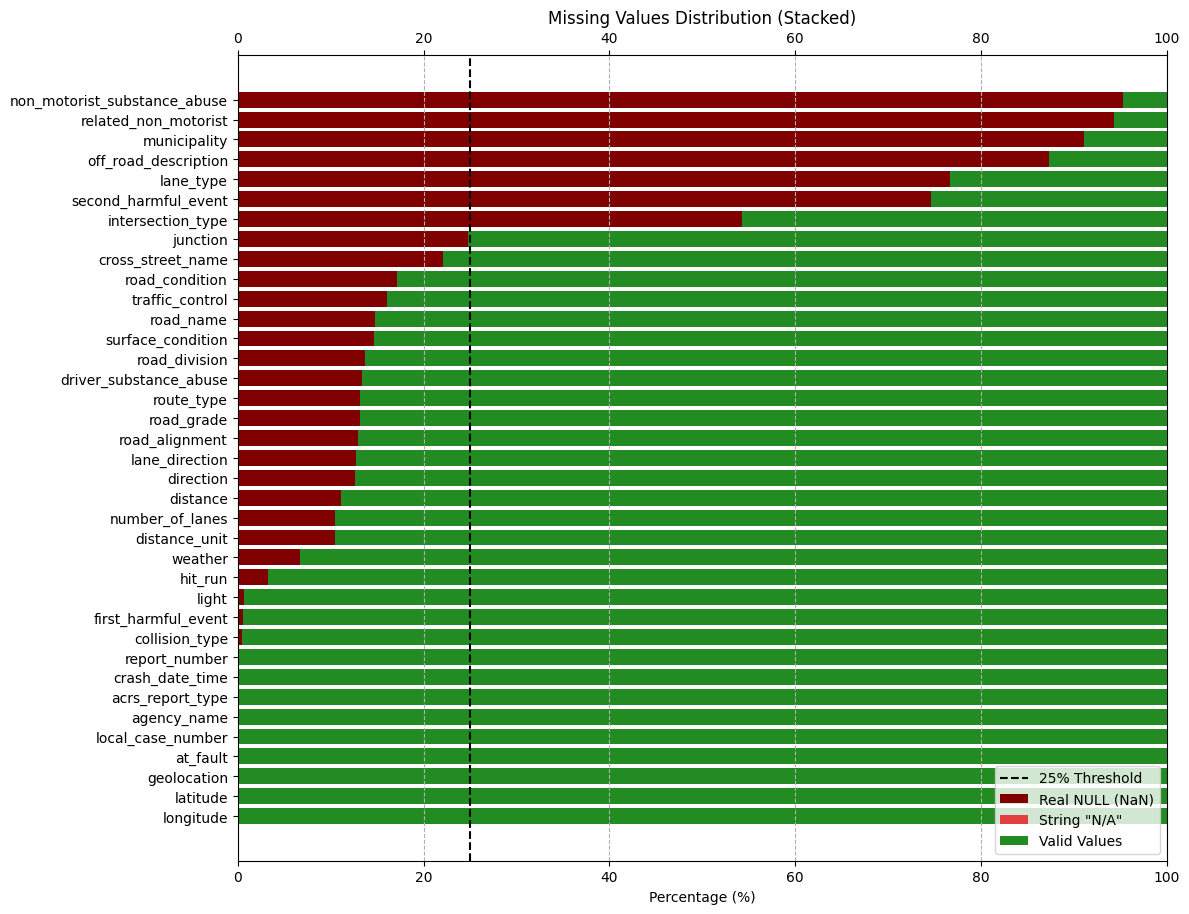

In [6]:
# code by LLM
real_nulls = df.isna().sum() / len(df) * 100
string_nas = (df == "N/A").sum() / len(df) * 100
valid_vals = 100 - (real_nulls + string_nas)

# ארגון DataFrame לעבודה נוחה ולמיון
cols = df.columns
df_plot = pd.DataFrame({
    'real_nulls': real_nulls,
    'string_nas': string_nas,
    'valid_vals': valid_vals
}, index=cols)

# מיין לפי real_nulls יורד
df_plot_sorted = df_plot.sort_values('real_nulls', ascending=False)

y = np.arange(len(df_plot_sorted))

fig, ax = plt.subplots(figsize=(12, max(6, len(df_plot_sorted)*0.25)))

ax.barh(y, df_plot_sorted['real_nulls'], color='#800000', label='Real NULL (NaN)')
ax.barh(y, df_plot_sorted['string_nas'], left=df_plot_sorted['real_nulls'], color='#e43f3f', label='String "N/A"')
ax.barh(y, df_plot_sorted['valid_vals'], left=df_plot_sorted['real_nulls'] + df_plot_sorted['string_nas'], color='#228b22', label='Valid Values')


ax.axvline(x=25, color='black', linestyle='--', linewidth=1.5, label='25% Threshold')

ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='x', which='both', labeltop=True, labelbottom=True)

ax.set_xlabel('Percentage (%)')
ax.set_title('Missing Values Distribution (Stacked)')
ax.set_yticks(y)
ax.set_yticklabels(df_plot_sorted.index)
ax.invert_yaxis() 
ax.set_xlim(0, 100)
ax.legend(loc='lower right', bbox_to_anchor=(1, 0))
ax.grid(axis='x', linestyle='--')

plt.tight_layout()
plt.show()

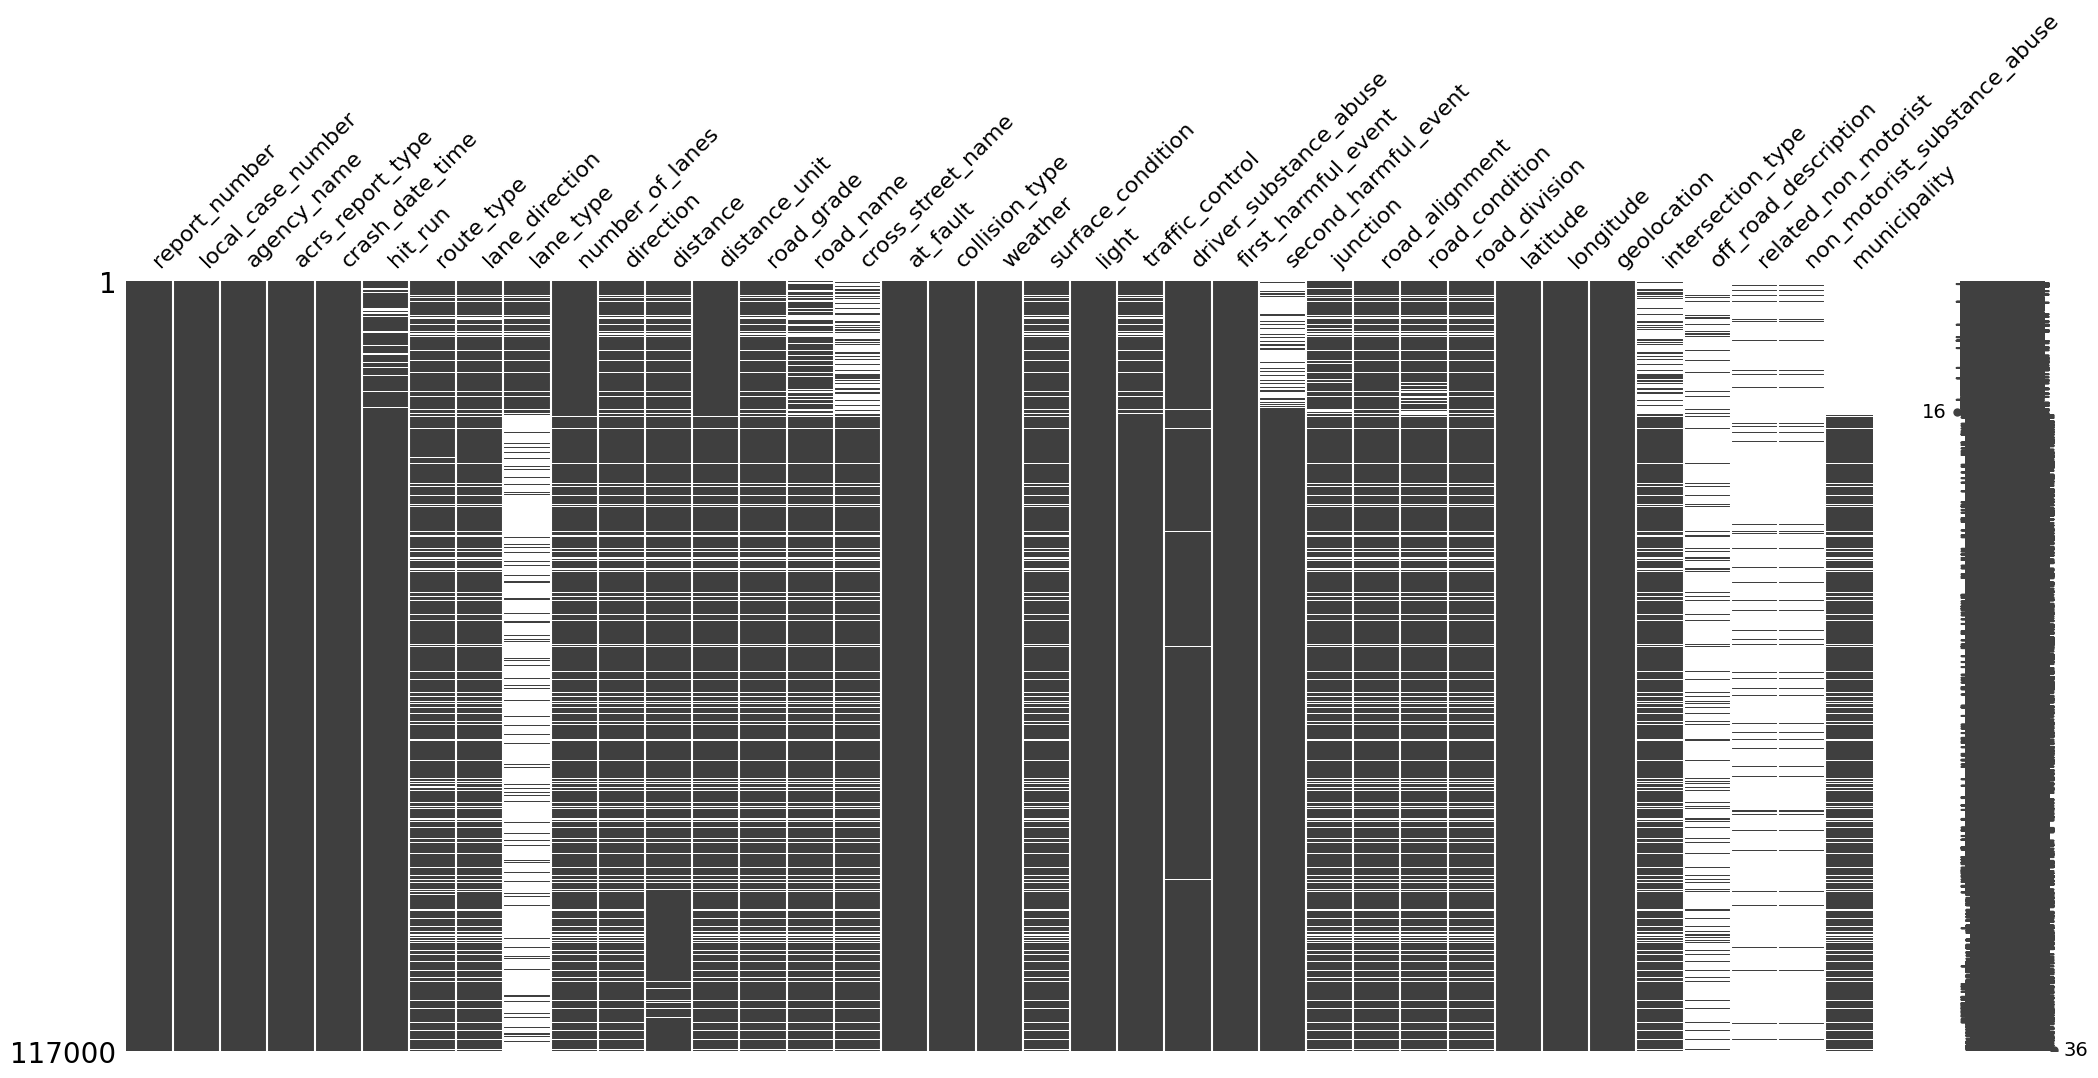

In [7]:
msno.matrix(df_original);

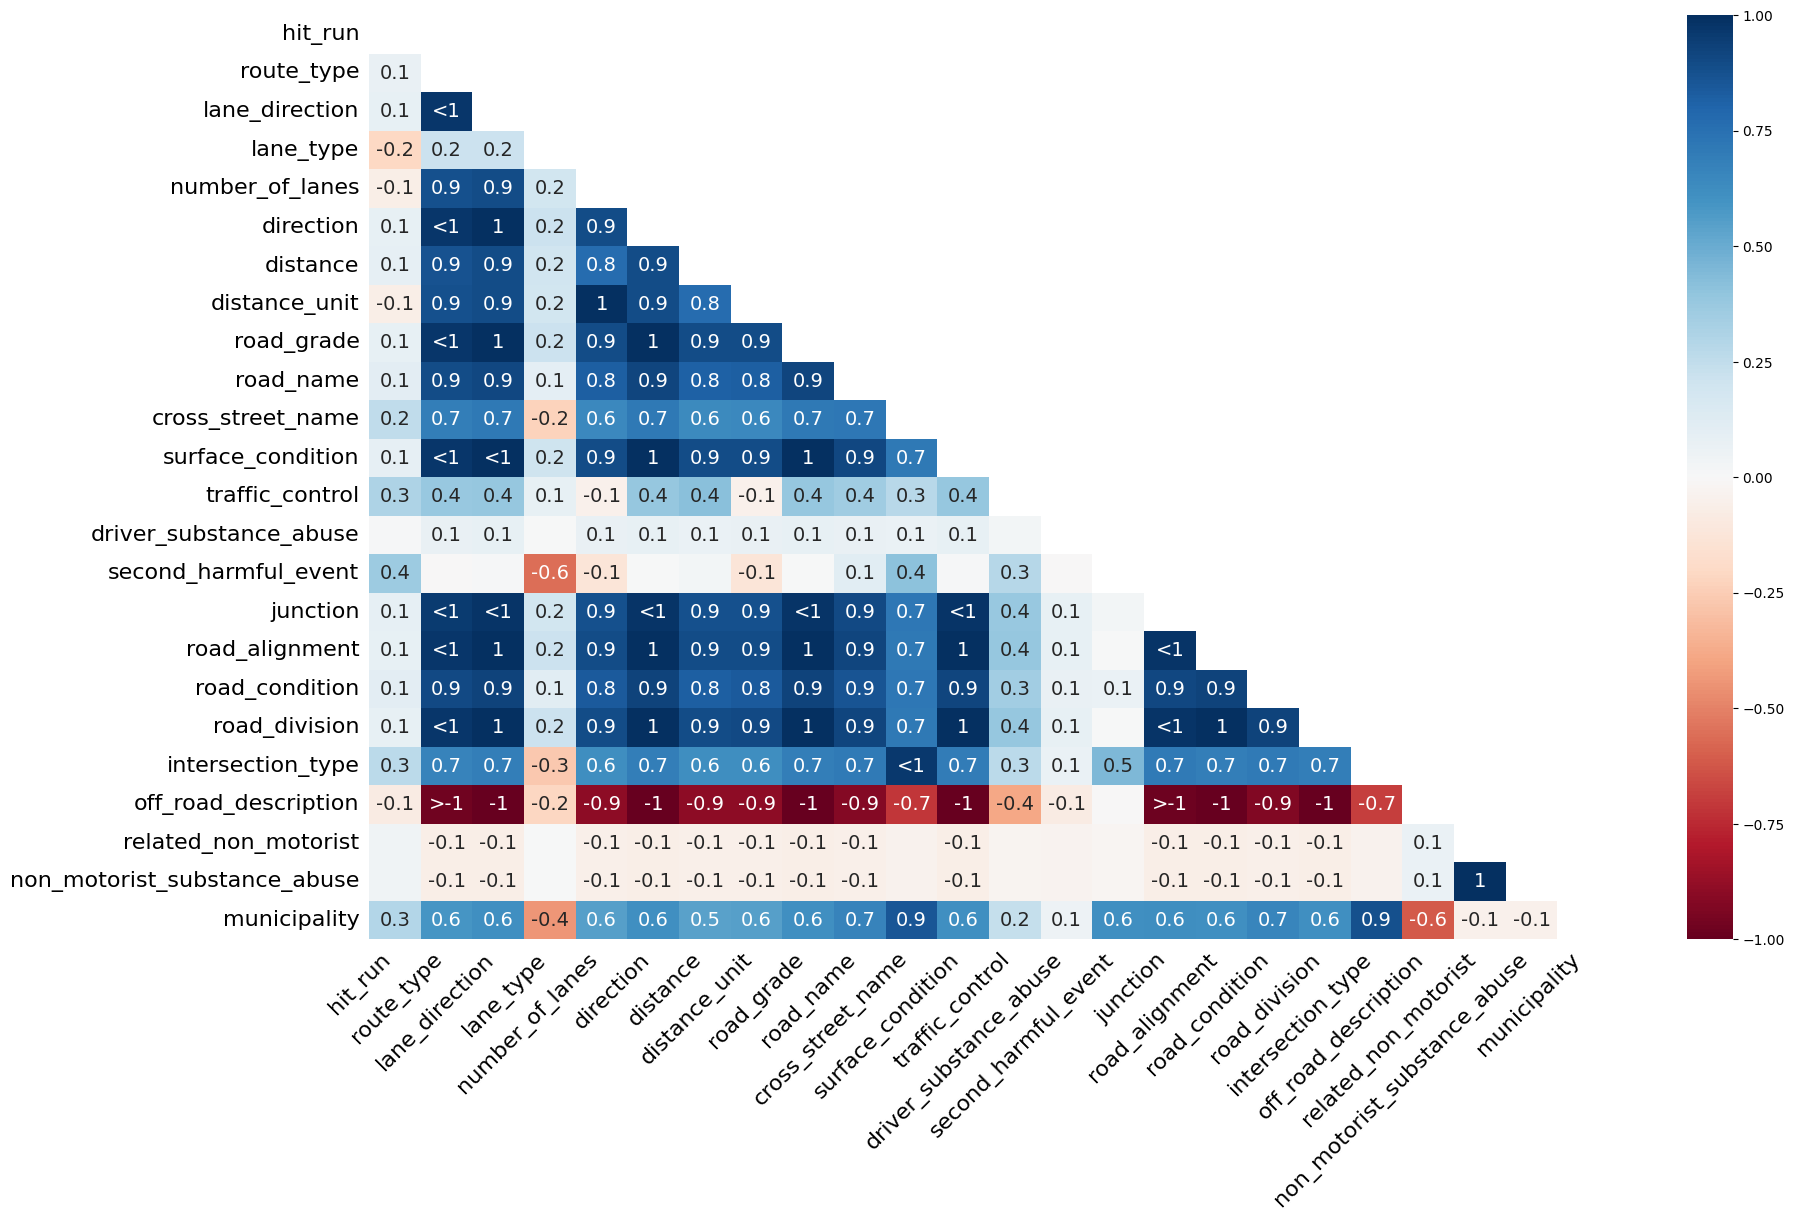

In [8]:
msno.heatmap(df_original);

ניתן לראות קורלציות בין הערכים החסרים בעמודות וקורלציה שלילית עם עמודת off road, באופן גס אפשר לחלק לשני קבוצות -   
1. תאונות שקרו בכביש ("הגוש הכחול")
2. תאונות שלא קרו בכביש, ולכן יש ערכים חסרים בהרבה עמודות שקשורות לתאונות על כביש  

לבדוק את החלוקה הזו נראה אם אכן ניתן להסביר את הערכים החסרים ב"גוש הכחול" על ידי עמודת off road

In [9]:
# code by LLM
# הגדרת קבוצות עמודות
mask_off_road = df['off_road_description'].notna()

strong_corr = ['lane_direction', 'number_of_lanes', 'road_alignment', 
               'road_condition', 'road_division', 'surface_condition',
               'direction', 'road_grade', 'road_name', 'distance', 
               'distance_unit', 'junction']

medium_corr = ['traffic_control', 'cross_street_name', 'intersection_type']

# חישוב מדדים
results = []
for col in strong_corr + medium_corr:
    unexplained_count = df.loc[df[col].isna() & ~mask_off_road].shape[0]
    results.append({
        'Feature': col,
        'group': 'strong' if col in strong_corr else 'medium',
        'Off-Road Missing %': df.loc[mask_off_road, col].isna().mean() * 100,
        'Unexplained Count': unexplained_count,
        'Unexplained %': unexplained_count / len(df) * 100
    })

res = pd.DataFrame(results)

# עיצוב
def color_by_group(row):
    color = '#15508D' if row['group'] == 'strong' else '#337EB8'
    return [f'background-color: {color}; color: white; font-weight: bold;'] + [''] * (len(row)-1)

styled = (res.style
    .apply(color_by_group, axis=1)
    .background_gradient(subset=['Off-Road Missing %'], cmap='Greens', vmin=0, vmax=100)
    .background_gradient(subset=['Unexplained %'], cmap='Reds', vmin=0, vmax=5)
    .format({'Off-Road Missing %': '{:.1f}%', 'Unexplained Count': '{:,}', 'Unexplained %': '{:.2f}%'})
    .hide(subset=['group'], axis='columns')
    .hide(axis='index'))

print(f"Total Off-Road Rows Identified: {mask_off_road.sum()}")
display(styled)

Total Off-Road Rows Identified: 14788


Feature,Off-Road Missing %,Unexplained Count,Unexplained %
lane_direction,100.0%,61,0.05%
number_of_lanes,82.7%,15,0.01%
road_alignment,100.0%,421,0.36%
road_condition,99.4%,"5,385",4.60%
road_division,100.0%,"1,189",1.02%
surface_condition,100.0%,"2,409",2.06%
direction,100.0%,11,0.01%
road_grade,100.0%,635,0.54%
road_name,100.0%,"2,444",2.09%
distance,85.2%,433,0.37%


מסקנה - רוב מוחלט של החסרים בגוש הכחול מוסברים ע"י ערכים בעמודת off road  
 יש 4 עמודות שלא מוסברות במלואן (הגבוה באדומים) כלומר קיים בהן ערכים חסרים וגם בoff road
ויש עוד 4 עמודות(הנמוכים בירוקים) (3 מתוכן גם ככה נזרוק) בערכים בoff road לא מסבירים את החברים אצלם

#הסבר מאיליאור על זה ועל כל עניין ההשלמה
השלמה גורפת -  
יש הרבה מהערכים בoff road שהם חניונים והן גם בהלימה לערכים החסרים ב"גוש הכחול"

אולי כדאי לעשות את הבדיקות חסרים למעלה גם עם ההמרה הזו

# Preprocessing

## Data Cleaning & Standardization

### Utility Functions

In [10]:
# code by LLM

def normalize_categorial_feature(x):
    '''
    Normalizes categorical text data by converting to lowercase, stripping whitespace,
    normalizing unicode characters, and replacing common null-like strings with NaN.
    '''
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = unicodedata.normalize('NFKC', s).strip().lower()
    if s in ["n/a", "none", "nan", "null", ""]:
        return np.nan
    s = re.sub(r'\s+', ' ', s)
    return s

def beauty_value_counts(df, column_name, color='#d65f5f'):
    """
    Generates a styled DataFrame showing counts and percentages 
    with a progress-bar visual for a specific categorical column.
    """
    # 1. Calculate value counts
    counts = df[column_name].value_counts(dropna=False)
    Percentage = df[column_name].value_counts(normalize=True, dropna=False) * 100
    
    # 2. Create the summary DataFrame
    # We use counts.sum() to calculate percentage relative to data
    summary_df = pd.DataFrame({
        'Count': counts,
        'Percentage': Percentage
    })
    
    # 3. Apply the bar style to the Percentage column
    styled_result = (summary_df.style
        .format({'Percentage': '{:.1f}%'}) # Format as percentage with 1 decimal
        .bar(subset=['Percentage'], color=color, vmin=0, vmax=100) # Add the visual bar
        .set_caption(f"Distribution of {column_name}") # Add a title to the table
        .set_table_styles([{'selector': 'caption', 
                            'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    )
    
    return styled_result



def display_side_by_side(*args):
    html_str = ''
    for df in args:
        # אם זה סטיילר (כמו הטבלה הצבעונית שיצרנו) לוקחים את ה-HTML שלו, אחרת ממירים
        if hasattr(df, 'to_html'):
            table_html = df.to_html() 
        else:
            table_html = df.render() # לסטיילרים של פנדס
            
        # עוטפים בדיב עם רווח
        html_str += f'<div style="margin-right: 20px">{table_html}</div>'
        
    # מציגים הכל בשורה אחת (Flexbox)
    display_html(f'<div style="display: flex;">{html_str}</div>', raw=True)

### Road Condition

In [11]:
df['road_condition'] = df['road_condition'].apply(normalize_categorial_feature)

In [12]:
df['road_condition'].unique()

array(['no defects', nan, 'unknown', 'view obstructed', 'not applicable',
       'other', 'holes ruts etc', 'loose surface material',
       'foreign material', 'shoulder defect', 'obstruction not signaled',
       'obstruction not lighted'], dtype=object)

In [13]:
# code by LLM

road_condition_mapping = {
    # --- Normal Condition (Baseline) ---
    'no defects': 'Normal',
    'not applicable': 'Normal',

    # --- Permanent Infrastructure Issues (Requires engineering repair/paving) ---
    'holes ruts etc': 'Infrastructure Defect', 
    'shoulder defect': 'Infrastructure Defect', # Shoulders are considered part of the infrastructure

    # --- Temporary Hazards (Requires immediate cleaning/maintenance) ---
    'loose surface material': 'Temporary Hazard', # Gravel, sand, oil spills
    'foreign material': 'Temporary Hazard',       # Fallen objects, debris

    # --- Signage & Visibility Issues (Requires vegetation trimming or electrical work) ---
    'view obstructed': 'Visibility/Signage',      # Vegetation, buildings blocking view
    'obstruction not signaled': 'Visibility/Signage',
    'obstruction not lighted': 'Visibility/Signage',

    # --- Unknown (Noise) ---
    'unknown': 'Unknown',
    'other': 'Unknown'
}

df["road_condition"] = df["road_condition"].map(road_condition_mapping).fillna(df["road_condition"])

In [14]:
beauty_value_counts(df, 'road_condition')

,Count,Percentage
road_condition,,
Normal,95403,81.5%
nan,20080,17.2%
Unknown,663,0.6%
Infrastructure Defect,422,0.4%
Temporary Hazard,313,0.3%
Visibility/Signage,119,0.1%


### Off Road Description

In [15]:
# 1. הגדרת התנאים (הוספנו את בדיקת החוסרים בהתחלה!)
conditions = [
    # --- השוער בשער: האם הערך חסר? ---
    df['off_road_description'].isna(),
    
    # --- אם לא חסר, ממשיכים לבדיקות הרגילות ---
    df['off_road_description'].str.contains('sidewalk', case=False, na=False),
    df['off_road_description'].str.contains('alley', case=False, na=False),
    df['off_road_description'].str.contains('parking|lot|garage', case=False, na=False),
    df['off_road_description'].str.contains('driveway', case=False, na=False),
    df['off_road_description'].str.contains('private road|pvt', case=False, na=False),
    df['off_road_description'].str.contains('service road', case=False, na=False),
    df['off_road_description'].str.contains('gas', case=False, na=False),
    df['off_road_description'].str.contains('school|university|college', case=False, na=False),
    df['off_road_description'].str.contains('shopping|center|mall', case=False, na=False),
    df['off_road_description'].str.contains('bus|metro|station', case=False, na=False),
    df['off_road_description'].str.contains('yard', case=False, na=False)
]

# 2. הגדרת התוצאות (חייב להתאים לסדר התנאים!)
choices = [
    None,  # התוצאה עבור התנאי הראשון (ערך חסר נשאר חסר)
    'Sidewalk',
    'Alley',
    'Parking',
    'Driveway',
    'Private Road',
    'Service Road',
    'Gas Station',
    'School Zone',
    'Commercial Area',
    'Transit Station',
    'Yard'
]

# 3. דריסת העמודה המקורית
# default='Other' -> כל מה שיש לו טקסט אבל לא נכנס לקטגוריות יקבל 'Other'
df['off_road_description'] = np.select(conditions, choices, default='Other')


beauty_value_counts(df, 'off_road_description')

,Count,Percentage
off_road_description,,
None,102212,87.4%
Parking,12087,10.3%
Other,1486,1.3%
Driveway,463,0.4%
Transit Station,131,0.1%
School Zone,119,0.1%
Commercial Area,115,0.1%
Alley,112,0.1%
Sidewalk,81,0.1%


In [16]:
#הורדת איזורים שלא רלוונטים למטרת המודל
values_to_drop = ["Private Road", "Gas Station", "Yard"]

df.drop(index=df.index[df["off_road_description"].isin(values_to_drop)],inplace=True)

### Route Type

In [17]:
df['route_type'].unique()

array(['Maryland (State) Route', 'Spur', 'County Route',
       'Municipality Route', 'Interstate (State)', None,
       'Government Route', 'Local Route', 'Other Public Roadway',
       'US (State)', 'Bicycle Route', 'Ramp', 'Crossover',
       'Private Route', 'Service Road', 'County', 'Maryland (State)',
       'Municipality', 'Government', 'Unknown'], dtype=object)

In [18]:
df['route_type'] = df['route_type'].apply(normalize_categorial_feature)

In [19]:
route_type_map = {
    # 1. Highways
    'maryland (state)': 'Highway',
    'maryland (state) route': 'Highway',
    'us (state)': 'Highway',
    'interstate (state)': 'Highway',

    # 2. Local Roads (Includes Gov/Private because they act like local roads)
    'county': 'Local',
    'county route': 'Local',
    'municipality': 'Local',
    'municipality route': 'Local',
    'local route': 'Local',
    'other public roadway': 'Local', 
    'government': 'Local',           
    'government route': 'Local',     
    'private route': 'Local',        
    'service road': 'Local',         

    # 3. Ramps (Unique behavior)
    'ramp': 'Ramp/ Spur',
    'spur': 'Ramp/ Spur',

    # 4. Other / Special Infrasructure
    'crossover': 'Other',
    'bicycle route': 'Other',
    'unknown': 'Other'
}

df["route_type"] = df["route_type"].map(route_type_map).fillna(df["route_type"])

In [20]:
beauty_value_counts(df, 'route_type')

,Count,Percentage
route_type,,
Highway,51380,44.0%
Local,48908,41.9%
nan,15299,13.1%
Ramp/ Spur,874,0.7%
Other,381,0.3%


In [21]:
# code by LLM
# בדיקת שפיות שהאיחוד תקין ואין פה דחיסה של התנהגיות חריגות לאותן קבוצות
pd.crosstab(df['route_type'], df['acrs_report_type'], normalize='index').style.background_gradient(cmap='Blues')


acrs_report_type,Fatal Crash,Injury Crash,Property Damage Crash
route_type,,,
Highway,0.004282,0.387155,0.608564
Local,0.002822,0.338922,0.658256
Other,0.000000,0.354331,0.645669
Ramp/ Spur,0.001144,0.337529,0.661327


### Junction

In [22]:
df['junction'].unique() 

array(['Non-Junction', 'Intersection or Related', 'Through Roadway',
       'Entrance/Exit Ramp or Related', 'Driveway Access or Related',
       None, 'Crossover-Related', 'Acceleration/Deceleration Lane',
       'Other Location Not Listed Above Within an Interchange Area (median,\nshoulder and roadside)',
       'Shared-Use Path or Trail', 'Railway Grade Crossing', <NA>,
       'INTERSECTION', 'NON INTERSECTION', 'INTERSECTION RELATED',
       'OTHER', 'OTHER DRIVEWAY', 'INTERCHANGE RELATED',
       'COMMERCIAL DRIVEWAY', 'CROSSOVER RELATED', 'RESIDENTIAL DRIVEWAY',
       'UNKNOWN', 'ALLEY', 'RAILWAY GRADE CROSSING'], dtype=object)

In [23]:
df['junction'] = df['junction'].apply(normalize_categorial_feature)

In [24]:
junction_map = {
    # --- Intersection ---
    'intersection or related': 'Intersection',
    'intersection': 'Intersection',
    'intersection related': 'Intersection',
    
    # --- Non-Junction ---
    'non-junction': 'Non-Junction',
    'non intersection': 'Non-Junction',
    'through roadway': 'Non-Junction',
    
    # --- Interchange/Ramp ---
    'entrance/exit ramp or related': 'Interchange/Ramp',
    'interchange related': 'Interchange/Ramp',
    'acceleration/deceleration lane': 'Interchange/Ramp',
    'other location not listed above within an interchange area (median, shoulder and roadside)': 'Interchange/Ramp',
    
    # --- Driveway ---
    'driveway access or related': 'Driveway',
    'commercial driveway': 'Driveway',
    'residential driveway': 'Driveway',
    'other driveway': 'Driveway',
    'crossover-related': 'Driveway', # מתנהג תחבורתית כמו פנייה/חצייה וגם התפלגויות דומות מול עמודת המטרה
    'crossover related': 'Driveway',
    
    # --- Other ---
    'other': 'Other',
    'alley': 'Other',
    'shared-use path or trail': 'Other',
    'railway grade crossing': 'Other',
    'unknown': 'Other' 
}

df['junction'] = df['junction'].map(junction_map).fillna(df["junction"])

In [25]:
beauty_value_counts(df, 'junction')

,Count,Percentage
junction,,
Intersection,48295,41.3%
Non-Junction,33477,28.7%
nan,28840,24.7%
Driveway,3159,2.7%
Interchange/Ramp,2013,1.7%
Other,1058,0.9%


### Intersection Type

In [26]:
df['intersection_type'] = df['intersection_type'].apply(normalize_categorial_feature)

In [27]:
beauty_value_counts(df, 'intersection_type')

,Count,Percentage
intersection_type,,
nan,63297,54.2%
four-way intersection,30339,26.0%
t-intersection,13737,11.8%
perpendicular,4485,3.8%
other,2561,2.2%
angled/skewed,1032,0.9%
y-intersection,643,0.6%
roundabout,302,0.3%
five-point or more,200,0.2%


לאחר בדיקה במפות באמת איך נראים הצמתים עולה כי המילוי כאן לא אחיד וחופף והקטגוריות כאן מבולבולת. בכיכרות התיוג הוא כן מדויק וגם ניתן לראות שאל מול עמודת המטרה הכיכרות מתנהגים שונה בניגוד לשאר הקטגוריות

In [28]:
pd.crosstab(
    df["intersection_type"],
    df["acrs_report_type"],
    normalize="index"
).style.background_gradient()

acrs_report_type,Fatal Crash,Injury Crash,Property Damage Crash
intersection_type,,,
angled/skewed,0.003876,0.397287,0.598837
five-point or more,0.000000,0.375000,0.625000
four-way intersection,0.003065,0.424965,0.571970
other,0.003514,0.360797,0.635689
perpendicular,0.006020,0.445485,0.548495
roundabout,0.003311,0.198675,0.798013
roundabout/traffic circle,0.000000,0.264706,0.735294
t-intersection,0.003421,0.397103,0.599476
traffic circle,0.000000,0.170940,0.829060


In [29]:
intersection_map = {
    # Roundabouts / Traffic Circles
    'roundabout': 'Roundabout',
    'traffic circle': 'Roundabout',
    'roundabout/traffic circle': 'Roundabout',
    
    # Regular Intersections
    'four-way intersection': 'Intersection',
    't-intersection': 'Intersection',
    'y-intersection': 'Intersection',
    'perpendicular': 'Intersection',
    'angled/skewed': 'Intersection',
    'five-point or more': 'Intersection',
    
    # Other / Unknown
    'other': 'Other',
    'unknown': 'Other'
}

df['intersection_type'] = df['intersection_type'].map(intersection_map).fillna(df["intersection_type"])

In [30]:
beauty_value_counts(df, 'intersection_type')

,Count,Percentage
intersection_type,,
nan,63297,54.2%
Intersection,50436,43.2%
Other,2656,2.3%
Roundabout,453,0.4%


### Surface Condition

In [31]:
df['surface_condition'].unique()

array(['Dry', 'Wet', None, 'Ice/Frost', 'Snow', 'Slush',
       'Mud, Dirt, Gravel', 'Other', 'Water (standing, moving)', 'Oil',
       'Sand', 'DRY', <NA>, 'WET', 'ICE', 'WATER(STANDING/MOVING)',
       'UNKNOWN', 'SNOW', 'SLUSH', 'OTHER', 'MUD, DIRT, GRAVEL', 'OIL',
       'SAND'], dtype=object)

In [32]:
df['surface_condition'] = df['surface_condition'].apply(normalize_categorial_feature)

In [33]:
# #בסוף לא השתמשנו
# surface_condition_map = {
#     # Wet
#     'wet': 'Wet',
#     'water (standing, moving)': 'Wet',
#     'water(standing/moving)': 'Wet',

#     # Ice/Snow/Slush
#     'ice': 'Ice_Snow',
#     'ice/frost': 'Ice_Snow',
#     'snow': 'Ice_Snow',
#     'slush': 'Ice_Snow',

#     # Debris/Oil
#     'mud, dirt, gravel': 'Debris_Oil',
#     'mud_dirt': 'Debris_Oil',
#     'sand': 'Debris_Oil',
#     'oil': 'Debris_Oil',

#     # Dry
#     'dry': 'Dry',

#     # Unknown/Other
#     'unknown': 'Unknown',
#     'other': 'Other'
# }

# df['surface_condition_simple'] = df['surface_condition'].map(surface_condition_map).fillna(df["surface_condition"])


In [34]:
surface_condition_map = {
    # === Dry ===
    'dry': 'Dry',

    # === Wet / Water ===
    'wet': 'Wet',
    'water (standing, moving)': 'Wet',
    'water(standing/moving)': 'Wet',

    # === Low friction: Ice / Snow / Slush ===
    'ice': 'Low_Friction',
    'ice/frost': 'Low_Friction',
    'snow': 'Low_Friction',
    'slush': 'Low_Friction',

    # === Contaminated surface: dirt / sand / oil ===
    'mud, dirt, gravel': 'Other',
    'mud_dirt': 'Other',
    'sand': 'Other',
    'oil': 'Other',
    'other': 'Other',

    # === Unknown ===
    'unknown': 'Unknown'
}

In [35]:
df['surface_condition'] = df['surface_condition'].map(surface_condition_map).fillna(df["surface_condition"])

In [36]:
beauty_value_counts(df, 'surface_condition')

,Count,Percentage
surface_condition,,
Dry,79094,67.7%
Wet,18512,15.8%
nan,17038,14.6%
Low_Friction,1610,1.4%
Unknown,403,0.3%
Other,185,0.2%


### Lane direction

In [37]:
df['lane_direction'].unique()

array(['Northbound', 'Westbound', 'Southbound', 'Northbound, Unknown',
       'Eastbound', None, 'Eastbound, Southbound', 'Eastbound, Westbound',
       'Northbound, Westbound', 'Eastbound, Northbound, Westbound',
       'Northbound, Not On Roadway', 'Not On Roadway, Southbound',
       'Unknown', 'Northbound, Southbound', 'Southbound, Westbound',
       'Eastbound, Northbound', 'Not On Roadway',
       'Not On Roadway, Westbound', 'Eastbound, Not On Roadway',
       'Eastbound, Northbound, Southbound',
       'Northbound, Southbound, Westbound', 'Not On Roadway, Unknown',
       'Eastbound, Southbound, Westbound', 'Eastbound, Unknown',
       'Southbound, Unknown', 'Eastbound, Not On Roadway, Southbound',
       'Unknown, Westbound', 'Not On Roadway, Southbound, Unknown',
       'Not On Roadway, Southbound, Westbound',
       'Northbound, Unknown, Westbound',
       'Eastbound, Northbound, Southbound, Westbound',
       'Northbound, Southbound, Unknown',
       'Northbound, Not On Roa

In [38]:
df['lane_direction'] = df['lane_direction'].apply(normalize_categorial_feature)

בדיקה - האם צורת הכיתוב השונה קשורה לשנים או לסוכנויות?

In [39]:
# code by LLM
# בואו נראה אם יש חפיפה זמנית
print("התפלגות לפי שנה:")
df['crash_year'] = pd.to_datetime(df['crash_date_time']).dt.year

# קידוד פשוט
simple = df[df['lane_direction'].isin(['north','south','east','west'])]
print(f"Simple coding years: {simple['crash_year'].value_counts().sort_index()}")

# קידוד מורכב  
complex = df[df['lane_direction'].str.contains('bound', na=False)]
print(f"Complex coding years: {complex['crash_year'].value_counts().sort_index()}")

# האם אותו agency משתמש בשני הקידודים?
print("\nAgencies using simple:")
print(simple['agency_name'].value_counts().head())

print("\nAgencies using complex:")
print(complex['agency_name'].value_counts().head())

התפלגות לפי שנה:
Simple coding years: crash_year
2015     9243
2016    10499
2017    10420
2018    10305
2019    10046
2020     6971
2021     8051
2022     8751
2023     9358
Name: count, dtype: int64
Complex coding years: crash_year
2023       1
2024    9042
2025    8266
Name: count, dtype: int64

Agencies using simple:
agency_name
Montgomery County Police     67578
MONTGOMERY                    5231
Rockville Police Departme     4794
Gaithersburg Police Depar     3504
Takoma Park Police Depart     1343
Name: count, dtype: int64

Agencies using complex:
agency_name
MONTGOMERY      14664
ROCKVILLE        1185
GAITHERSBURG     1020
TAKOMA            290
MCPARK            150
Name: count, dtype: int64


החליפו את צורת הכיתוב בשנת 2024  
אבל מה קורה עם הריבוי כיוונים?

בדיקות להבנת המשמעות של העמודה:

In [40]:
# code by LLM
def analyze_lane_directions(val):
    """
    פונקציה שמקבלת מחרוזת כיוונים ומחזירה 3 נתונים:
    1. מספר הכיוונים (num_directions)
    2. הקטגוריה המילולית (category)
    3. האם זה דו-סטרי (is_bidirectional)
    """
    # 1. טיפול בערכים חסרים
    if pd.isna(val):
        return pd.Series([np.nan, 'missing', False])
    
    val_str = str(val).lower()
    
    # 2. טיפול במקרים מיוחדים (טקסטואליים)
    if 'unknown' in val_str:
        return pd.Series([np.nan, 'unknown', False])
    
    if 'not on roadway' in val_str:
        return pd.Series([0, 'not_on_roadway', False])

    # 3. חילוץ הכיוונים הבסיסיים (סט כדי למנוע כפילויות)
    directions = set()
    if 'north' in val_str: directions.add('north')
    if 'south' in val_str: directions.add('south')
    if 'east'  in val_str: directions.add('east')
    if 'west'  in val_str: directions.add('west')
    
    count = len(directions)
    
    # 4. בדיקת דו-סטריות (מנוגדים)
    is_bi = False
    if ('north' in directions and 'south' in directions) or \
       ('east' in directions and 'west' in directions):
        is_bi = True

    # 5. קביעת הקטגוריה (הלוגיקה שלך)
    category = 'other'
    if count == 0:
        category = 'no_direction'
    elif count == 1:
        category = 'single_direction'
    elif count == 2:
        category = 'opposite_directions' if is_bi else 'adjacent_directions'
    elif count == 3:
        category = 'three_directions'
    elif count >= 4:
        category = 'four_directions'
        
    return pd.Series([count, category, is_bi])

# --- הפעלת הפונקציה על הדאטה ---
# שימוש ב-apply שמחזיר 3 עמודות בבת אחת
new_cols = ['num_directions', 'lane_category', 'is_bidirectional']
df[new_cols] = df['lane_direction'].apply(analyze_lane_directions)

In [41]:
# code by LLM
dist_1 = beauty_value_counts(df, 'lane_category')
dist_2 = beauty_value_counts(df, 'num_directions', color='#4c72b0')
dist_3 = beauty_value_counts(df, 'is_bidirectional', color='#5fba7d')

display_side_by_side(dist_1, dist_2, dist_3)

,Count,Percentage
lane_category,,
single_direction,96316,82.4%
missing,14688,12.6%
adjacent_directions,2270,1.9%
opposite_directions,1954,1.7%
unknown,1060,0.9%
not_on_roadway,411,0.4%
three_directions,141,0.1%
four_directions,2,0.0%
,Count,Percentage


In [42]:
# code by LLM
# --- בדיקות ואימות (Validation) ---
print("\n=== 1. בדיקת הצלבה מול סוג התאונה ===")
# יצירת ה-Crosstab
cross_tab = pd.crosstab(df['lane_category'], df['collision_type'], normalize='index')
# רשימת מילות מפתח שנחפש (באותיות קטנות) כדי לתפוס את כל הווריאציות
# זה יתפוס גם את 'STRAIGHT MOVEMENT ANGLE', גם את 'Front to Rear', וגם את 'HEAD ON'
keywords = ['angle', 'rear', 'head on', 'front to front', 'front to rear']
# סינון העמודות: נציג עמודה רק אם אחת ממילות המפתח מופיעה בה (ללא חשיבות ל-Upper/Lower case)
cols_to_show = [c for c in cross_tab.columns if any(k in str(c).lower() for k in keywords)]
# הצגת הטבלה עם צבעים להדגשה
display(cross_tab[cols_to_show].style.background_gradient(cmap='Reds', axis=0).format("{:.1%}"))

print("\n=== 2. בדיקת הצלבה מול צמתים ===")
# האם 'four_directions' באמת מתרחש בצמתים?
display(pd.crosstab(df['lane_category'], df['junction'].fillna('missing'),normalize='index')\
        .style.background_gradient(cmap='Reds', axis=None).format("{:.1%}"))


print("\n=== 3. בדיקת הצלבה מול סוג הדרך ===")
# האם יש קשר בין קטגוריית הכיוונים לסוג הדרך?
display(pd.crosstab(df['lane_category'], df['route_type'],normalize='index')\
        .style.background_gradient(cmap='Reds', axis=None).format("{:.1%}"))


=== 1. בדיקת הצלבה מול סוג התאונה ===


collision_type,ANGLE MEETS LEFT HEAD ON,ANGLE MEETS LEFT TURN,ANGLE MEETS RIGHT TURN,Angle,Front to Front,Front to Rear,HEAD ON,HEAD ON LEFT TURN,Rear To Rear,Rear To Side,SAME DIR REAR END,STRAIGHT MOVEMENT ANGLE
lane_category,,,,,,,,,,,,
adjacent_directions,0.0%,0.0%,0.0%,58.1%,9.0%,3.5%,0.0%,0.0%,0.1%,12.7%,0.0%,0.0%
four_directions,0.0%,0.0%,0.0%,50.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
missing,0.2%,0.2%,0.2%,1.7%,0.8%,2.4%,1.8%,0.9%,1.0%,1.2%,5.0%,7.5%
not_on_roadway,0.0%,0.0%,0.0%,16.1%,6.3%,12.9%,0.0%,0.0%,1.7%,5.4%,0.0%,0.0%
opposite_directions,0.0%,0.0%,0.0%,39.1%,21.9%,4.0%,0.0%,0.0%,0.4%,6.8%,0.0%,0.0%
single_direction,0.3%,1.0%,0.6%,1.2%,0.3%,4.8%,1.8%,6.3%,0.1%,0.2%,25.8%,14.5%
three_directions,0.0%,0.0%,0.0%,53.2%,10.6%,2.1%,0.0%,0.0%,0.0%,9.9%,0.0%,0.0%
unknown,0.4%,0.6%,0.2%,3.3%,0.9%,5.1%,2.1%,5.4%,1.0%,1.1%,4.4%,8.9%



=== 2. בדיקת הצלבה מול צמתים ===


junction,Driveway,Interchange/Ramp,Intersection,Non-Junction,Other,missing
lane_category,,,,,,
adjacent_directions,6.9%,3.4%,70.7%,16.7%,0.0%,2.3%
four_directions,0.0%,0.0%,50.0%,50.0%,0.0%,0.0%
missing,0.1%,0.0%,0.0%,0.3%,0.0%,99.6%
not_on_roadway,11.7%,4.6%,9.5%,69.3%,0.0%,4.9%
opposite_directions,6.1%,3.1%,49.8%,38.9%,0.0%,2.0%
single_direction,2.9%,1.9%,47.0%,32.9%,1.0%,14.4%
three_directions,5.0%,1.4%,80.9%,12.1%,0.0%,0.7%
unknown,6.4%,2.0%,25.8%,33.1%,7.5%,25.1%



=== 3. בדיקת הצלבה מול סוג הדרך ===


route_type,Highway,Local,Other,Ramp/ Spur
lane_category,,,,
adjacent_directions,30.9%,63.8%,2.3%,3.0%
four_directions,0.0%,100.0%,0.0%,0.0%
missing,15.3%,81.4%,3.4%,0.0%
not_on_roadway,20.5%,75.6%,2.7%,1.2%
opposite_directions,34.6%,61.4%,2.1%,1.9%
single_direction,51.9%,47.1%,0.3%,0.8%
three_directions,37.6%,57.4%,2.8%,2.1%
unknown,22.5%,75.4%,0.8%,1.4%


מסקנה: הכיוונים מייצגים את הכיוון שעליו נסעו הרכבים המעורבים בתאונה (לכן לפעמים יש יותר מכיוון אחד)

מה זה not_on_roadway?

In [43]:
# code by LLM
# בדיקת חפיפה: איפה פיזית מתרחשים המקרים של "לא על הכביש"?
cross_check = pd.crosstab(df['lane_category'], df['route_type'])

# נתמקד רק בשורה הרלוונטית ונציג באחוזים
not_on_road_distribution = cross_check.loc['not_on_roadway'].sort_values(ascending=False)
print("=== Where do 'not_on_roadway' accidents happen? ===")
print(not_on_road_distribution)
print("\nPercentage in Parking Lots:")
total = not_on_road_distribution.sum()
parking = not_on_road_distribution.get('Parking_Lot', 0)
print(f"{parking} out of {total} ({parking/total:.1%})")

# בדיקה הפוכה: מה קורה בתוך חניונים? האם כולם "לא על הכביש"?
print("\n=== Reverse Check: What is the lane direction inside Parking Lots? ===")
print(df[df['route_type'] == 'Parking_Lot']['lane_category'].value_counts())

=== Where do 'not_on_roadway' accidents happen? ===
route_type
Local         309
Highway        84
Other          11
Ramp/ Spur      5
Name: not_on_roadway, dtype: int64

Percentage in Parking Lots:
0 out of 409 (0.0%)

=== Reverse Check: What is the lane direction inside Parking Lots? ===
Series([], Name: count, dtype: int64)


שתי תובנות:  
1. not_on_roadway מסתמן כרכב שלא חניון או משהו רגוע כמו שחשבנו
2. מסתבר שהרבה ערכים חסרים אצלנו הם חניונים.. בכללי זה יכול להיות רלוונטי בעוד עמודות חסרות?

=== Risk Analysis by Lane Category (Sorted by Severity) ===


acrs_report_type,Fatal Crash,Injury Crash,Property Damage Crash,Total_Severe_Risk
lane_category,,,,
three_directions,0.0%,60.3%,39.7%,60.3%
four_directions,0.0%,50.0%,50.0%,50.0%
opposite_directions,0.8%,43.9%,55.3%,44.7%
adjacent_directions,0.1%,44.1%,55.7%,44.3%
single_direction,0.4%,36.1%,63.5%,36.5%
not_on_roadway,0.0%,27.5%,72.5%,27.5%
unknown,0.1%,22.7%,77.2%,22.8%
missing,0.0%,16.4%,83.6%,16.4%


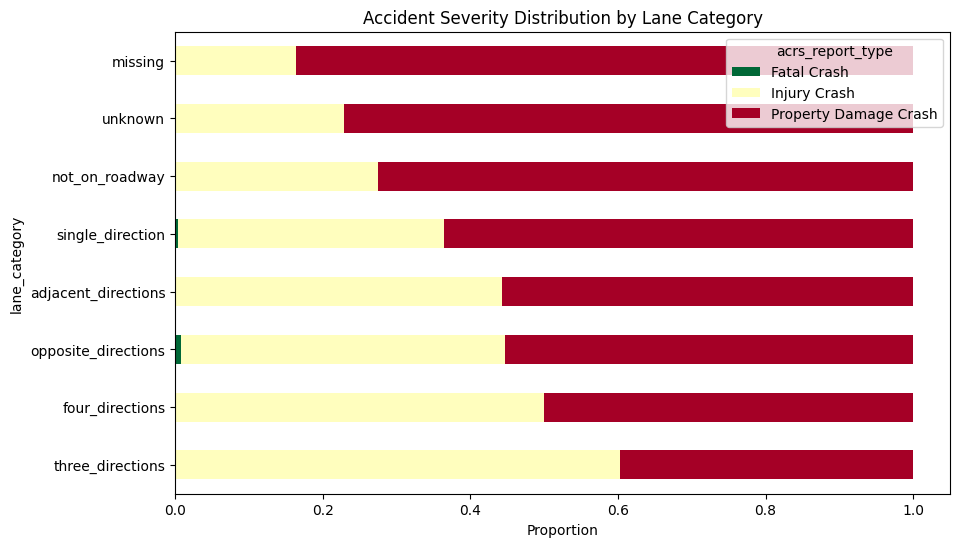

In [44]:
# code by LLM
# הגדרת עמודת המטרה (תשנה ל-report_type או injury_severity בהתאם לדאטה שלך)
target_col = 'acrs_report_type' 

# 1. יצירת טבלת שכיחויות (באחוזים)
risk_analysis = pd.crosstab(df['lane_category'], df[target_col], normalize='index')

# 2. ננסה לזהות את הטורים של התאונות הקשות כדי למיין לפיהם
# (נניח שיש טורים כמו 'FATAL', 'INJURY', או 'SUSPECTED SERIOUS INJURY')
# נחפש טורים שמכילים מילים מחשידות
severe_cols = [c for c in risk_analysis.columns if 'FATAL' in str(c).upper() or 'INJURY' in str(c).upper() or 'SERIOUS' in str(c).upper()]

if len(severe_cols) > 0:
    # חישוב "ציון סיכון" - סכום האחוזים של העמודות הקשות
    risk_analysis['Total_Severe_Risk'] = risk_analysis[severe_cols].sum(axis=1)
    
    # מיון מהמסוכן לבטוח
    risk_analysis = risk_analysis.sort_values('Total_Severe_Risk', ascending=False)
    
    # הצגת התוצאה עם צבעים
    print(f"=== Risk Analysis by Lane Category (Sorted by Severity) ===")
    display(risk_analysis.style.background_gradient(cmap='Reds', subset=['Total_Severe_Risk']).format("{:.1%}"))
    
    # ויזואליזציה מהירה
    import matplotlib.pyplot as plt
    risk_analysis.drop(columns=['Total_Severe_Risk']).plot(kind='barh', stacked=True, figsize=(10, 6), colormap='RdYlGn_r')
    plt.title('Accident Severity Distribution by Lane Category')
    plt.xlabel('Proportion')
    plt.show()

else:
    # אם לא מצאנו מילים, נציג רגיל
    display(risk_analysis.style.background_gradient(cmap='Blues').format("{:.1%}"))

In [45]:
# חניונים(Missing -> Parking Behavior)

df.loc[df['route_type'] == 'Parking_Lot', 'lane_category'] = 'parking_behavior'

#  איחוד זנב ארוך
# זה יעזור למודל לזהות "אזור סכנה בצומת"
df['lane_category'] = df['lane_category'].replace(['three_directions', 'four_directions', 'adjacent_directions'], 'complex_intersection')

In [46]:
beauty_value_counts(df, 'lane_category')

,Count,Percentage
lane_category,,
single_direction,96316,82.4%
missing,14688,12.6%
complex_intersection,2413,2.1%
opposite_directions,1954,1.7%
unknown,1060,0.9%
not_on_roadway,411,0.4%


- האם המסקנה של יצירת עמודה של סוג נתיב לא קשורה למחשבה שזה הגאומטריה?
- להסביר את שתי התובנות שהוא כתב קודם

In [47]:
df["lane_category"].value_counts()

lane_category
single_direction        96316
missing                 14688
complex_intersection     2413
opposite_directions      1954
unknown                  1060
not_on_roadway            411
Name: count, dtype: int64

In [48]:
# ct = pd.crosstab(
#     df['is_bidirectional'].fillna('<Missing>'),
#     df['is_two_way'].fillna('<Missing>')
# )
# display(ct.style.background_gradient(axis= None))

### Crash Date Time

In [49]:
df['crash_date_time'] = pd.to_datetime(df['crash_date_time'])

In [50]:
df['hour'] = df['crash_date_time'].dt.hour
df['month'] = df['crash_date_time'].dt.month
df['day_of_week'] = df['crash_date_time'].dt.dayofweek # 0=Monday, 6=Sunday

df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

def get_time_of_day(hour):
    if 5 <= hour < 11:
        return 'Morning'   
    elif 11 <= hour < 15:
        return 'Mid_day'       
    elif 15 <= hour < 20:
        return 'Evening'   
    else:
        return 'Night'          
df['time_of_day'] = df['hour'].apply(get_time_of_day)

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

# code by LLM
us_holidays = holidays.US(state='MD') 

def is_holiday(date_obj):
    return 1 if date_obj in us_holidays else 0

df['is_holiday'] = df['crash_date_time'].apply(is_holiday)

# בדיקה
df[['crash_date_time', 'time_of_day', 'season', 'is_weekend', 'is_holiday']].head()

,crash_date_time,time_of_day,season,is_weekend,is_holiday
0,2025-12-24 03:45:00,Night,Winter,0,0
1,2025-12-22 17:40:00,Evening,Winter,0,0
2,2025-12-20 05:10:00,Morning,Winter,1,0
3,2025-12-19 21:30:00,Night,Winter,0,0
4,2025-12-19 19:23:00,Evening,Winter,0,0


### Road Grade

In [51]:
df['road_grade'] = df['road_grade'].apply(normalize_categorial_feature)

In [52]:
beauty_value_counts(df, 'road_grade')

,Count,Percentage
road_grade,,
level,78064,66.8%
nan,15262,13.1%
grade downhill,9742,8.3%
hill uphill,7238,6.2%
hill crest,2157,1.8%
downhill,1378,1.2%
uphill,1328,1.1%
"downhill, uphill",332,0.3%
"downhill, level",253,0.2%


In [53]:
road_grade_map = {
    "level": "Level",
    "downhill": "Downhill",
    "uphill": "Uphill",
    "other": "Other",
    "grade downhill": "Downhill",
    "hill crest": "Hillcrest",
    "hill uphill": "Uphill",
    "dip sag": "Sag",
    "sag(bottom)": "Sag",
    "level, sag(bottom)": "Level,Sag",
    "downhill, sag(bottom)": "Downhill,Sag",
    "sag(bottom), uphill": "Sag,Uphill",
    "downhill,level": "Downhill,Level",
    "level,uphill": "Level,Uphill",
    "hillcrest": "Hillcrest",
    "on bridge": "On Bridge",
    "unknown": "Level"
}

In [54]:
# code by LLM
#שימוש במילון והסרת רווחים לפני ואחרי הפסיק כדי להכין למולטי הוט
df["road_grade"] = df["road_grade"].map(road_grade_map).fillna(df["road_grade"])
df["road_grade"] = df["road_grade"].astype("string").str.replace(r"\s*,\s*", ",", regex=True)
df['road_grade'] = df['road_grade'].apply(lambda x: str(x).title() if pd.notna(x) else x)

In [55]:
beauty_value_counts(df, 'road_grade')

,Count,Percentage
road_grade,,
Level,78215,66.9%
,15262,13.1%
Downhill,11120,9.5%
Uphill,8566,7.3%
Hillcrest,2319,2.0%
"Downhill,Uphill",332,0.3%
"Downhill,Level",253,0.2%
"Level,Uphill",251,0.2%
Other,188,0.2%


In [56]:
road_grade_aggressive_map = {
    "Downhill,Uphill": "Combination",
    "Downhill,Level": "Combination",
    "hill uphill": "Combination",
    "Level,Uphill": "Combination",
    "Hillcrest,Uphill": "Combination",
    "Downhill,Level,Uphill": "Combination",
    "Downhill,Hillcrest": "Combination",
    "Level,Sag(Bottom)": "Combination",
    "Downhill,Sag(Bottom)	": "Combination",
    "Hillcrest,Level,Uphill": "Combination",
    "Sag(Bottom),Uphill": "Combination",
    "Other": "Combination",
    "Hillcrest,Level": "Combination",
    "Downhill,Sag(Bottom)": "Combination",
    "Level,Sag": "Combination",
    "Downhill,Sag": "Combination",
    "Sag,Uphill": "Combination"
}

In [57]:
df["road_grade_cat"] = df["road_grade"].map(road_grade_aggressive_map).fillna(df["road_grade"])

In [58]:
beauty_value_counts(df, 'road_grade_cat')

,Count,Percentage
road_grade_cat,,
Level,78215,66.9%
,15262,13.1%
Downhill,11120,9.5%
Uphill,8566,7.3%
Hillcrest,2319,2.0%
Combination,1120,1.0%
Sag,168,0.1%
On Bridge,72,0.1%


In [59]:
# code by LLM
# Minimal multi-hot (assumes road_grade is already standardized and comma-cleaned)
dummies = (
    df["road_grade"]
      .fillna("")
      .astype("string")
      .str.get_dummies(sep=",")
)

dummies.columns = dummies.columns.str.replace(" ", "_", regex=False)  # "on bridge" -> "on_bridge"
dummies = dummies.add_prefix("road_grade_").astype("int8")

df = df.join(dummies)

In [60]:
#בדיקה
df[["road_grade"] + [c for c in df.columns if c.startswith("road_grade_")]].head()

,road_grade,road_grade_cat,road_grade_Downhill,road_grade_Hillcrest,road_grade_Level,road_grade_On_Bridge,road_grade_Other,road_grade_Sag,road_grade_Uphill
0,Level,Level,0,0,1,0,0,0,0
1,Level,Level,0,0,1,0,0,0,0
2,Level,Level,0,0,1,0,0,0,0
3,Level,Level,0,0,1,0,0,0,0
4,Uphill,Uphill,0,0,0,0,0,0,1


### Road Alignment

להוסיף את הצגת הקורלציות להסבר שזה כנראה שני הרכבים

In [61]:
df['road_alignment'] = df['road_alignment'].apply(normalize_categorial_feature)

In [62]:
# code by LLM
#שימוש במילון והסרת רווחים לפני ואחרי הפסיק כדי להכין למולטי הוט
df["road_alignment"] = df["road_alignment"].astype("string").str.replace(r"\s*,\s*", ",", regex=True)
df['road_alignment'] = df['road_alignment'].apply(lambda x: str(x).title() if pd.notna(x) else x)

In [63]:
df['road_alignment'] = df['road_alignment'].replace('Unknown', 'Straight')

In [64]:
beauty_value_counts(df, 'road_alignment')

,Count,Percentage
road_alignment,,
Straight,89269,76.4%
,15047,12.9%
Curve Right,5929,5.1%
Curve Left,5626,4.8%
Other,529,0.5%
"Curve Left,Curve Right",167,0.1%
"Curve Left,Straight",152,0.1%
"Curve Right,Straight",119,0.1%
"Curve Left,Curve Right,Straight",4,0.0%


In [65]:
# code by LLM
# Minimal multi-hot (assumes road_alignment is already standardized and comma-cleaned)
dummies = (
    df["road_alignment"]
      .fillna("")
      .astype("string")
      .str.get_dummies(sep=",")
)

dummies.columns = dummies.columns.str.replace(" ", "_", regex=False)  # "on bridge" -> "on_bridge"
dummies = dummies.add_prefix("road_alignment_").astype("int8")

df = df.join(dummies)

In [66]:
#בדיקה
df[["road_alignment"] + [c for c in df.columns if c.startswith("road_alignment_")]].head()

,road_alignment,road_alignment_Curve_Left,road_alignment_Curve_Right,road_alignment_Other,road_alignment_Straight
0,Straight,0,0,0,1
1,Straight,0,0,0,1
2,Straight,0,0,0,1
3,Straight,0,0,0,1
4,Straight,0,0,0,1


In [67]:
road_alignment_aggressive_map = {
    "Curve Left,Curve Right": "Combination",
    "Curve Left,Straight": "Combination",
    "Curve Right,Straight": "Combination",
    "Curve Left,Curve Right,Straight": "Combination"
}

In [68]:
df["road_alignment_cat"] = df["road_alignment"].map(road_alignment_aggressive_map).fillna(df["road_alignment"])

In [69]:
beauty_value_counts(df, 'road_alignment_cat')

,Count,Percentage
road_alignment_cat,,
Straight,89269,76.4%
,15047,12.9%
Curve Right,5929,5.1%
Curve Left,5626,4.8%
Other,529,0.5%
Combination,442,0.4%


### Road Division

In [70]:
df['road_division'] = df['road_division'].apply(normalize_categorial_feature)

In [71]:
df["road_division"].unique()

array(['divided, raised median (curbed)', 'not divided',
       'divided, raised median (curbed), not divided',
       'divided, depressed median', nan,
       'divided, flush median (greater than 4ft wide)',
       'not divided, not divided, with a continuous left-turn lane',
       'not divided, with a continuous left-turn lane',
       'divided, flush median (greater than 4ft wide), not divided',
       'divided, flush median (greater than 4ft wide), not divided, with a continuous left-turn lane',
       'divided, flush median (greater than 4ft wide), divided, raised median (curbed)',
       'divided, raised median (curbed), not divided, with a continuous left-turn lane',
       'not divided, unknown',
       'divided, flush median (greater than 4ft wide), divided, raised median (curbed), not divided, with a continuous left-turn lane',
       'divided, depressed median, divided, flush median (greater than 4ft wide)',
       'divided, depressed median, divided, raised median (curbed)

In [72]:
# code by LLM
road_division_map = {
    # one-way
    "one-way trafficway": "one-way, not relevant, not relevant, not relevant",

    # two-way (explicit)
    "two-way, not divided": "two-way, not divided, not relevant, nan",
    "two-way, not divided with a continuous left turn": "two-way, not divided, not relevant, continuous left-turn lane",
    "two-way, divided, positive median barrier": "two-way, divided, unknown median type, nan",
    "two-way, divided, unprotected painted min 4 feet": "two-way, divided, flush median, nan",

    # not divided (generic)
    "not divided": "two-way, not divided, not relevant, nan",
    ", not divided": "two-way, not divided, not relevant, nan",
    "not divided, unknown": "two-way, not divided, not relevant, nan",

    # not divided + continuous left-turn lane
    "not divided, with a continuous left-turn lane": "two-way, not divided, not relevant, continuous left-turn lane",
    "not divided, not divided, with a continuous left-turn lane": "two-way, not divided, not relevant, continuous left-turn lane",
    "not divided, with a continuous left-turn lane, unknown": "two-way, not divided, not relevant, continuous left-turn lane",

    # divided: raised median
    "divided, raised median (curbed)": "two-way, divided, raised median, nan",
    "divided, raised median (curbed), unknown": "two-way, divided, raised median, nan",
    "divided, raised median (curbed), not divided": "two-way, divided, raised median, nan",
    "divided, raised median (curbed), not divided, with a continuous left-turn lane": "two-way, divided, raised median, continuous left-turn lane",
    "divided, raised median (curbed), not divided, not divided, with a continuous left-turn lane": "two-way, divided, raised median, continuous left-turn lane",
    # divided: flush median
    "divided, flush median (greater than 4ft wide)": "two-way, divided, flush median, nan",
    "divided, flush median (greater than 4ft wide), not divided": "two-way, divided, flush median, nan",
    "divided, flush median (greater than 4ft wide), unknown": "two-way, divided, flush median, nan",
    "divided, flush median (greater than 4ft wide), not divided, with a continuous left-turn lane": "two-way, divided, flush median, continuous left-turn lane",
    "divided, flush median (greater than 4ft wide), not divided, not divided, with a continuous left-turn lane": "two-way, divided, flush median, continuous left-turn lane",

    # divided: depressed median
    "divided, depressed median": "two-way, divided, depressed median, nan",
    "divided, depressed median, unknown": "two-way, divided, depressed median, nan",
    "divided, depressed median, not divided": "two-way, divided, depressed median, nan",
    "divided, depressed median, not divided, with a continuous left-turn lane": "two-way, divided, depressed median, continuous left-turn lane",

    # depressed + flush (mixed) and depressed + flush + not divided (mixed)
    "divided, depressed median, divided, flush median (greater than 4ft wide)": "two-way, divided, other median, nan",
    "divided, depressed median, divided, flush median (greater than 4ft wide), not divided": "two-way, divided, other median, nan",

    # depressed + raised (mixed)
    "divided, depressed median, divided, raised median (curbed)": "two-way, divided, other median, nan",

    # depressed + flush + raised (mixed)
    "divided, depressed median, divided, flush median (greater than 4ft wide), divided, raised median (curbed)": "two-way, divided, other median, nan",

    # flush + raised (mixed)
    "divided, flush median (greater than 4ft wide), divided, raised median (curbed)": "two-way, divided, other median, nan",
    "divided, flush median (greater than 4ft wide), divided, raised median (curbed), not divided": "two-way, divided, other median, nan",
    "divided, flush median (greater than 4ft wide), divided, raised median (curbed), not divided, with a continuous left-turn lane": "two-way, divided, other median, continuous left-turn lane",

    # raised + not divided + not divided is not in your unique list as a standalone key, but keep safe if appears
    "divided, raised median (curbed), not divided, not divided": "two-way, divided, raised median, nan",

    # raised + not divided + left-turn already handled above, but keep safe if appears in slightly different order
    "divided, raised median (curbed), not divided, not divided, with a continuous left-turn lane": "two-way, divided, raised median, continuous left-turn lane",

    # unknown / other
    "unknown": "nan, nan, nan, nan",
    "other": "nan, nan, nan, nan",
}

In [73]:
df["road_division_cat"] = df["road_division"].map(road_division_map).fillna(df["road_division"])

In [74]:
#הוספת נתיב שמאלה אם מופיע בעמודת lane_type
df.loc[
    df["road_division_cat"].eq("nan, nan, nan, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "nan, nan, nan, continuous left-turn lane"
df.loc[
    df["road_division_cat"].eq("two-way, divided, unknown median type, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "two-way, divided, unknown median type, continuous left-turn lane"
df.loc[
    df["road_division_cat"].eq("two-way, not divided, not_relevant, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "two-way, not divided, not_relevant, continuous left-turn lane"
df.loc[
    df["road_division_cat"].eq("two-way, divided, flush median, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "two-way, divided, flush median, continuous left-turn lane"
df.loc[
    df["road_division_cat"].eq("two-way, divided, raised median, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "two-way, divided, raised median, continuous left-turn lane"
df.loc[
    df["road_division_cat"].eq("two-way, divided, depressed median, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "two-way, divided, depressed median, continuous left-turn lane"
df.loc[
    df["road_division_cat"].eq("two-way, divided, other median, nan")
    & df["lane_type"].astype(str).str.contains("left turn lane", case=False, na=False),
    "road_division_cat"
] = "two-way, divided, other median, continuous left-turn lane"

In [75]:
df['road_division_cat'] = df['road_division_cat'].apply(lambda x: str(x).title() if pd.notna(x) else x)

In [76]:
beauty_value_counts(df, "road_division_cat")

,Count,Percentage
road_division_cat,,
"Two-Way, Not Divided, Not Relevant, Nan",38209,32.7%
"Two-Way, Divided, Unknown Median Type, Nan",37627,32.2%
nan,15814,13.5%
"Two-Way, Divided, Flush Median, Nan",10879,9.3%
"Two-Way, Divided, Raised Median, Nan",6080,5.2%
"One-Way, Not Relevant, Not Relevant, Not Relevant",1964,1.7%
"Two-Way, Divided, Unknown Median Type, Continuous Left-Turn Lane",1914,1.6%
"Nan, Nan, Nan, Nan",1274,1.1%
"Two-Way, Divided, Raised Median, Continuous Left-Turn Lane",865,0.7%


In [77]:
# code by LLM
#יצירת אופציה נוספת לטיפול בעמודה הזו - פיצול המידע
parts = df["road_division_cat"].astype(str).str.split(",", n=3, expand=True)
for c in parts.columns:
    parts[c] = parts[c].astype(str).str.strip().str.title()
parts = parts.replace({"None": np.nan, "nan": np.nan, "": np.nan})

df["is_two_way"] = parts[0]
df["division"] = parts[1]
df["division_type"] = parts[2]
df["left_turn"] = parts[3]

df["is_two_way"] = df["is_two_way"].map({"Two-Way": 1, "One-Way": 0})

In [78]:
df[["is_two_way", "division", "division_type", "left_turn"]].head(5)

,is_two_way,division,division_type,left_turn
0,1.0,Divided,Raised Median,Nan
1,1.0,Not Divided,Not Relevant,Nan
2,1.0,Not Divided,Not Relevant,Nan
3,1.0,Not Divided,Not Relevant,Nan
4,1.0,Divided,Raised Median,Nan


### Distance & Distance Unit

In [79]:
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')
df["longitude"] = pd.to_numeric(df['longitude'], errors='coerce')
df["latitude"] = pd.to_numeric(df['latitude'], errors='coerce')

In [80]:
beauty_value_counts(df, "distance_unit")

,Count,Percentage
distance_unit,,
FEET,98533,84.3%
None,12121,10.4%
MILE,5733,4.9%
UNKNOWN,455,0.4%


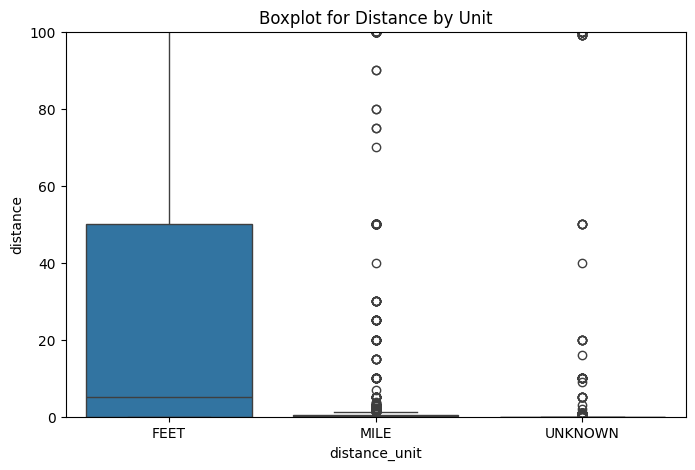

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='distance_unit', y='distance', data=df)
plt.ylim(0, 100)

plt.title("Boxplot for Distance by Unit")
plt.show()

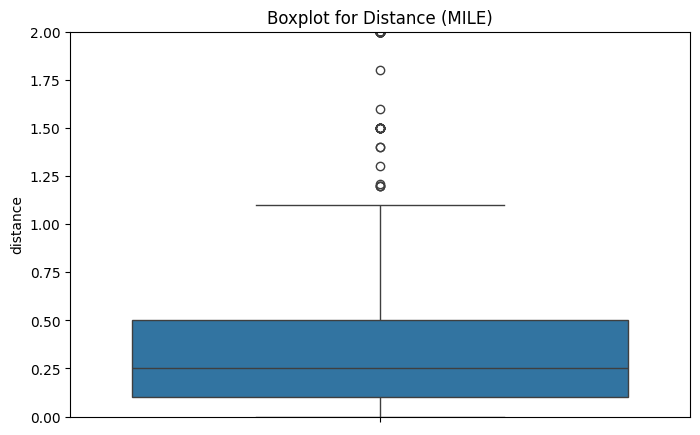

In [82]:
# סינון השורות שבהן distance_unit הוא 'MILE'
df_mile = df[df['distance_unit'] == 'MILE']

# יצירת בוקס פלוט רק עבור הערכים שבהם distance_unit = 'MILE'
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_mile['distance'])
plt.ylim(0, 2)

# הצגת הגרף
plt.title("Boxplot for Distance (MILE)")
plt.show()

In [83]:
df[df['distance_unit'] == 'MILE']['distance'].describe()

count    5369.000000
mean        6.371626
std        43.895167
min         0.000000
25%         0.100000
50%         0.250000
75%         0.500000
max       800.000000
Name: distance, dtype: float64

In [84]:
df[df['distance_unit'] == 'FEET']['distance'].describe()

count    95957.000000
mean        59.021319
std        136.102374
min          0.000000
25%          0.000000
50%          5.000000
75%         50.000000
max      10078.320000
Name: distance, dtype: float64

- יש 354 שורות שבהן המרחק הוא 0 ולכן אין יחידת מידה ואין צורך לבצע המרה
- נשארנו עם 102 שורות שצריך לקבוע מה יחידת המידה שלהן להמרה.

In [85]:
#המרת ערכים של פיט למייל
df.loc[df["distance_unit"] == "MILE", "distance"] = (
    df.loc[df["distance_unit"] == "MILE", "distance"] * 5280)

In [86]:
df["distance"].describe()

count    1.039470e+05
mean     1.792205e+03
std      5.319083e+04
min      0.000000e+00
25%      0.000000e+00
50%      5.260000e+00
75%      5.000000e+01
max      4.224000e+06
Name: distance, dtype: float64

In [87]:
df.loc[df["distance_unit"]== "UNKNOWN", "distance"] = np.nan

In [88]:
# 2) דגימה של הנתונים - לצורך הפחתת כמות הנקודות
df_sample = df.dropna(subset=["latitude", "longitude", "distance"]).sample(n=5000, random_state=42)

# 3) נרמול של עמודת distance בצורה יותר רגישה
def custom_scaling(value):
    """נרמול רגיש עבור distance, פרופורציות קטנות יותר לאפס וגדולות יותר בערכים גבוהים"""
    if value < 50:
        return value / 50
    elif value < 1000:
        return (value - 50) / (1000 - 50) * 0.9 + 0.1
    else:
        return (value - 1000) / (df_sample["distance"].max() - 1000) * 0.9 + 0.9

# 4) חישוב ערכים מנותחים של distance
df_sample["distance_scaled"] = df_sample["distance"].apply(custom_scaling)

# 5) יצירת צבעים על פי הערכים בעמודת distance
def get_color(value):
    """מחזיר צבע על פי הערך בעמודת distance"""
    if value < 0.2:
        return "lightblue"  # צבע בהיר למרחקים קטנים מאוד
    elif value < 0.4:
        return "blue"
    elif value < 0.6:
        return "darkblue"
    elif value < 0.8:
        return "navy"
    else:
        return "midnightblue"  # צבע כהה למרחקים גדולים

# 6) ליצור מפה בסיסית
center = [df_sample["latitude"].mean(), df_sample["longitude"].mean()]
m = folium.Map(location=center, zoom_start=11)

# 7) הוספת נקודות על המפה - כל נקודה צבעונית לפי ערך ה-distance
for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=(row["latitude"], row["longitude"]),
        radius=3,  # גודל הנקודה
        color=get_color(row["distance_scaled"]),
        fill=True,
        fill_color=get_color(row["distance_scaled"]),
        fill_opacity=0.7
    ).add_to(m)

# 8) כפתור לשכבות (אם אתה רוצה לאפשר שימוש בכפתור המאפשר כיבוי של הצגת הנקודות)
folium.LayerControl(collapsed=False).add_to(m)

# הצגת המפה
display(m)

In [89]:
# 2) דגימה של הנתונים - לצורך הפחתת כמות הנקודות
df_sample = df.dropna(subset=["latitude", "longitude", "distance"]).sample(n=10000, random_state=42)

# 3) נרמול של עמודת distance בצורה יותר רגישה
def custom_scaling(value):
    """נרמול רגיש עבור distance, פרופורציות קטנות יותר לאפס וגדולות יותר בערכים גבוהים"""
    if value < 50:
        return value / 50
    elif value < 1000:
        return (value - 50) / (1000 - 50) * 0.9 + 0.1
    else:
        return (value - 1000) / (df_sample["distance"].max() - 1000) * 0.9 + 0.9

# 4) חישוב ערכים מנותחים של distance
df_sample["distance_scaled"] = df_sample["distance"].apply(custom_scaling)

# 5) יצירת צבעים על פי הערכים בעמודת distance
def get_color(value):
    """מחזיר צבע על פי הערך בעמודת distance"""
    if value < 0.2:
        return "lightblue"  # צבע בהיר למרחקים קטנים מאוד
    elif value < 0.4:
        return "blue"
    elif value < 0.6:
        return "darkblue"
    elif value < 0.8:
        return "navy"
    else:
        return "midnightblue"  # צבע כהה למרחקים גדולים

# 6) ליצור מפה בסיסית
center = [df_sample["latitude"].mean(), df_sample["longitude"].mean()]
m = folium.Map(location=center, zoom_start=11)

# 7) הוספת נקודות על המפה - כל נקודה צבעונית לפי ערך ה-distance
for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=(row["latitude"], row["longitude"]),
        radius=3,  # גודל הנקודה
        color=get_color(row["distance_scaled"]),
        fill=True,
        fill_color=get_color(row["distance_scaled"]),
        fill_opacity=0.7
    ).add_to(m)

# 8) כפתור לשכבות (אם אתה רוצה לאפשר שימוש בכפתור המאפשר כיבוי של הצגת הנקודות)
folium.LayerControl(collapsed=False).add_to(m)

m.save("distance_map.html")

In [90]:
# 2) דגימה של הנתונים - לצורך הפחתת כמות הנקודות
df_sample = df.dropna(subset=["latitude", "longitude", "distance"]).sample(n=5000, random_state=42)

# 3) נרמול של עמודת distance בצורה יותר רגישה
def custom_scaling(value):
    """נרמול רגיש עבור distance, פרופורציות קטנות יותר לאפס וגדולות יותר בערכים גבוהים"""
    if value < 50:
        return value / 50
    elif value < 1000:
        return (value - 50) / (1000 - 50) * 0.9 + 0.1
    else:
        return (value - 1000) / (df_sample["distance"].max() - 1000) * 0.9 + 0.9

# 4) חישוב ערכים מנותחים של distance
df_sample["distance_scaled"] = df_sample["distance"].apply(custom_scaling)

# 5) סינון רק את הנתונים שבהם ה-distance גדול מ-50
df_filtered = df_sample[df_sample["distance"] > 50]

# 6) יצירת צבעים על פי הערכים בעמודת distance
def get_color(value):
    """מחזיר צבע על פי הערך בעמודת distance"""
    if value < 0.2:
        return "lightblue"  # צבע בהיר למרחקים קטנים מאוד
    elif value < 0.4:
        return "blue"
    elif value < 0.6:
        return "darkblue"
    elif value < 0.8:
        return "navy"
    else:
        return "midnightblue"  # צבע כהה למרחקים גדולים

# 7) ליצור מפה בסיסית
center = [df_filtered["latitude"].mean(), df_filtered["longitude"].mean()]
m = folium.Map(location=center, zoom_start=11)

# 8) הוספת נקודות על המפה - כל נקודה צבעונית לפי ערך ה-distance
for _, row in df_filtered.iterrows():
    folium.CircleMarker(
        location=(row["latitude"], row["longitude"]),
        radius=3,  # גודל הנקודה
        color=get_color(row["distance_scaled"]),
        fill=True,
        fill_color=get_color(row["distance_scaled"]),
        fill_opacity=0.7
    ).add_to(m)

# 9) כפתור לשכבות (אם אתה רוצה לאפשר שימוש בכפתור המאפשר כיבוי של הצגת הנקודות)
folium.LayerControl(collapsed=False).add_to(m)

# הצגת המפה
display(m)

In [91]:
# 2) דגימה של הנתונים - לצורך הפחתת כמות הנקודות
df_sample = df.dropna(subset=["latitude", "longitude", "distance"]).sample(n=10000, random_state=42)

# 3) נרמול של עמודת distance בצורה יותר רגישה
def custom_scaling(value):
    """נרמול רגיש עבור distance, פרופורציות קטנות יותר לאפס וגדולות יותר בערכים גבוהים"""
    if value < 50:
        return value / 50
    elif value < 1000:
        return (value - 50) / (1000 - 50) * 0.9 + 0.1
    else:
        return (value - 1000) / (df_sample["distance"].max() - 1000) * 0.9 + 0.9

# 4) חישוב ערכים מנותחים של distance
df_sample["distance_scaled"] = df_sample["distance"].apply(custom_scaling)

# 5) סינון רק את הנתונים שבהם ה-distance גדול מ-50
df_filtered = df_sample[df_sample["distance"] > 50]

# 6) יצירת צבעים על פי הערכים בעמודת distance
def get_color(value):
    """מחזיר צבע על פי הערך בעמודת distance"""
    if value < 0.2:
        return "lightblue"  # צבע בהיר למרחקים קטנים מאוד
    elif value < 0.4:
        return "blue"
    elif value < 0.6:
        return "darkblue"
    elif value < 0.8:
        return "navy"
    else:
        return "midnightblue"  # צבע כהה למרחקים גדולים

# 7) ליצור מפה בסיסית
center = [df_filtered["latitude"].mean(), df_filtered["longitude"].mean()]
m = folium.Map(location=center, zoom_start=11)

# 8) הוספת נקודות על המפה - כל נקודה צבעונית לפי ערך ה-distance
for _, row in df_filtered.iterrows():
    folium.CircleMarker(
        location=(row["latitude"], row["longitude"]),
        radius=3,  # גודל הנקודה
        color=get_color(row["distance_scaled"]),
        fill=True,
        fill_color=get_color(row["distance_scaled"]),
        fill_opacity=0.7
    ).add_to(m)

# 9) כפתור לשכבות (אם אתה רוצה לאפשר שימוש בכפתור המאפשר כיבוי של הצגת הנקודות)
folium.LayerControl(collapsed=False).add_to(m)

# שמירת המפה כקובץ HTML
m.save("filtered_distance_map.html")

נראה שנקודות כהות מופיעות על פני כל המפה. ההשערה שזה נובע מכמה סיבות:
1. הפיזור של ערכי המרחק לא רחב, הרוב 0 או קרוב
2. נקודת הייחוס היא צומת מרכזית לתאונה ולכן לכל תאונה יש מרחק קרובה מהצומת הקרובה, ולא מדובר במרחק מעיר מרכזית או נקודות מרכזיות בודדות במפה.

### Direction

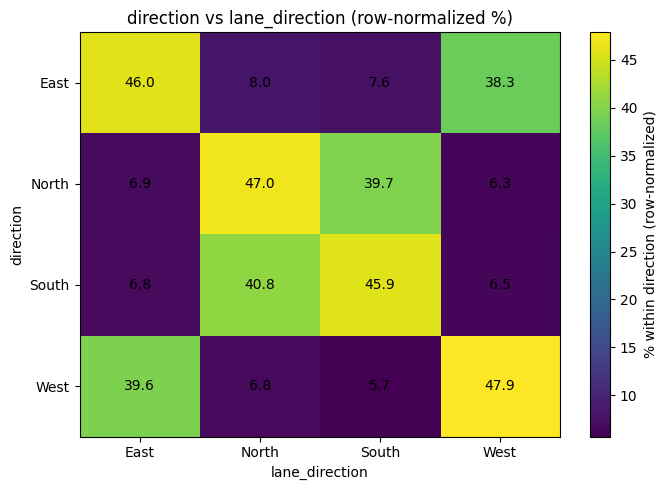

In [92]:
# code by LLM
#בדיקת הקשר בין כיוון וכיוון נתיב

vals = ["East", "North", "South", "West"]

d = df.copy()
d["direction"] = d["direction"].astype(str).str.strip().str.title()
d["lane_direction"] = d["lane_direction"].astype(str).str.strip().str.title()
d = d[d["direction"].isin(vals) & d["lane_direction"].isin(vals)]

ct = pd.crosstab(d["direction"], d["lane_direction"], normalize="index") * 100
ct = ct.reindex(index=vals, columns=vals).fillna(0)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ct.values, aspect="auto")
fig.colorbar(im, ax=ax, label="% within direction (row-normalized)")

ax.set_xticks(range(len(vals)))
ax.set_yticks(range(len(vals)))
ax.set_xticklabels(vals)
ax.set_yticklabels(vals)
ax.set_xlabel("lane_direction")
ax.set_ylabel("direction")
ax.set_title("direction vs lane_direction (row-normalized %)")

for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.iat[i, j]:.1f}", ha="center", va="center")

fig.tight_layout()

נראה שברוב המקרים העמודות direction ו-lane_direction נמצאים על אותו ציר של הכביש, ולכן ניתן לשער שעמודת הכיוון מציגה את הציר שבו המרחק מהצומת מחושב.

### Weather

In [93]:
df['weather'] = df['weather'].apply(normalize_categorial_feature)

In [94]:
weather_map = {
    "rain": "raining",
    "blowing snow": "Snow_Precipitation",
    "fog, smog, smoke": "other",
    "freezing rain or freezing drizzle": "Snow_Precipitation",
    "severe crosswinds": "other",
    "sleet or hail": "Snow_Precipitation",
    "blowing sand, soil, dirt": "other",
    "wintry mix": "Snow_Precipitation",
    "snow": "Snow_Precipitation",
    "severe winds": "other"}

In [95]:
df["weather"] = df["weather"].map(weather_map).fillna(df["weather"])
df['weather'] = df['weather'].apply(lambda x: str(x).title() if pd.notna(x) else x)

In [96]:
beauty_value_counts(df,'weather')

,Count,Percentage
weather,,
Clear,80834,69.2%
Raining,13689,11.7%
Cloudy,11313,9.7%
nan,7885,6.7%
Snow_Precipitation,1371,1.2%
Unknown,843,0.7%
Foggy,421,0.4%
Other,365,0.3%
Sleet,121,0.1%


### Light

In [97]:
df['light'] = df['light'].apply(normalize_categorial_feature)

In [98]:
light_map = {
    "dark lights on": "dark lighted",
    "dark - lighted": "dark lighted",
    "dark no lights": "dark",
    "dark -- unknown lighting": "dark - unknown lighting",
    "dark - not lighted": "dark",
    "dusk": "low natural light",
    "dawn": "low natural light",
    "unknown": "other"

}

In [99]:
df["light"] = df["light"].map(light_map).fillna(df["light"])
df['light'] = df['light'].apply(lambda x: str(x).title() if pd.notna(x) else x)

In [100]:
beauty_value_counts(df,'light')

,Count,Percentage
light,,
Daylight,76445,65.4%
Dark Lighted,28279,24.2%
Low Natural Light,4610,3.9%
Dark,4333,3.7%
Dark - Unknown Lighting,1248,1.1%
Other,1115,1.0%
nan,812,0.7%


### Traffic Control

In [101]:
df['traffic_control'] = df['traffic_control'].apply(normalize_categorial_feature)

In [102]:
def map_traffic_control(value):
    if pd.isnull(value):
        return pd.NA

    s = str(value)

    if "person" in s:
        return "person"
    elif "sign" in s or "signal" in s:
        return "traffic signal"
    elif value == "unknown":
        return "unknown"
    elif "pavement marking" in s or "pedestrian crossing" in s:
        return "other"
    elif "no controls" in s:
        return "no controls"
    else:
        return "other"

In [103]:
df['traffic_control'] = df['traffic_control'].apply(map_traffic_control).fillna(df["traffic_control"])
df['traffic_control'] = df['traffic_control'].apply(lambda x: str(x).title() if pd.notna(x) else x)

In [104]:
beauty_value_counts(df,'traffic_control')

,Count,Percentage
traffic_control,,
No Controls,50447,43.2%
Traffic Signal,45888,39.3%
nan,18709,16.0%
Other,1376,1.2%
Unknown,235,0.2%
Person,187,0.2%


### Agency Name

In [105]:
df['agency_name'] = df['agency_name'].apply(normalize_categorial_feature)

In [106]:
agency_map = {
    "montgomery": "montgomery county police",
    "gaithersburg": "gaithersburg police depart",
    "rockville": "rockville police departme",
    "takoma": "takoma park police depart",
    "mcpark": "montgomery county police"
}

In [107]:
df["agency_name"] = df["agency_name"].map(agency_map).fillna(df["agency_name"]).str.title()

In [108]:
beauty_value_counts(df,'agency_name')

,Count,Percentage
agency_name,,
Montgomery County Police,100538,86.0%
Rockville Police Departme,7321,6.3%
Gaithersburg Police Depar,4449,3.8%
Takoma Park Police Depart,2246,1.9%
Gaithersburg Police Depart,1499,1.3%
Maryland-National Capital,789,0.7%


### Number Of Lanes

In [109]:
#בדיקה לראות אם הערכים המוזרים בעמודה קשורים לגורם שמילא את הדוח
df[df['agency_name']=='gaithersburg police depart']['number_of_lanes'].value_counts() 

Series([], Name: count, dtype: int64)

צריך להוסיף כאן בדיקה יותר מסודרת

מסקנה: אין קשר בין המשטרה שהכניסה את הדוח לצורת מילוי הערכים בעמודה הזו. לא ברור מהם המספרים הגדולים והשילובים.

### Driver Substance Abuse

In [110]:
df['driver_substance_abuse'] = df['driver_substance_abuse'].apply(normalize_categorial_feature)

In [111]:
# code by LLM
def map_driver_substance(value):
    if pd.isna(value):
        return np.nan
    if re.search(
        r"(alcohol|drug|medication|substance|combination)\s+(present|contributed)", value):
        return 1
    if re.search(r"(?<!no )suspect of (alcohol|drug) use", value):
        return 1
    if re.search(r"(not|none)\s+(detected|suspect)", value):
        return 0
    if "unknown" in value:
        return np.nan
    else:
        return np.nan

In [112]:
df["driver_substance_abuse"] = df["driver_substance_abuse"].apply(map_driver_substance)

In [113]:
beauty_value_counts(df,'driver_substance_abuse')

,Count,Percentage
driver_substance_abuse,,
0.000000,68668,58.8%
1.000000,24756,21.2%
nan,23418,20.0%


### Latitude and Longitude

בדיקה האם יש ריכוז תאונות דווקא במרכז של תחום שיפוט של כל משטרה, כדי לבדוק את ההנחה שיש קשר למרכז ופריפרייה:

In [114]:
# code by LLM
# 1) לוודא lat/lon מספריים ולסנן תקינים
df["latitude"]  = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

df_map = df.dropna(subset=["latitude", "longitude"]).copy()
df_map["agency_name"] = df_map["agency_name"].fillna("Unknown").astype(str).str.strip()

# 2) לבחור רק את הסוכנויות המובילות (כדי שהמפה לא תהיה כבדה)
top_k = 8
top_agencies = df_map["agency_name"].value_counts().head(top_k).index.tolist()

df_map["agency_group"] = df_map["agency_name"].where(
    df_map["agency_name"].isin(top_agencies),
    "Other agencies"
)

# 3) להגדיר gradients שונים לכל שכבה
gradients = [
    {0.2: "blue",   0.6: "cyan",   1.0: "navy"},
    {0.2: "green",  0.6: "lime",   1.0: "darkgreen"},
    {0.2: "red",    0.6: "orange", 1.0: "darkred"},
    {0.2: "purple", 0.6: "violet", 1.0: "indigo"},
    {0.2: "brown",  0.6: "tan",    1.0: "saddlebrown"},
    {0.2: "black",  0.6: "gray",   1.0: "white"},
    {0.2: "pink",   0.6: "hotpink",1.0: "deeppink"},
    {0.2: "yellow", 0.6: "gold",   1.0: "orange"},
    {0.2: "teal",   0.6: "aqua",   1.0: "darkslategray"},  # ל-Other agencies
]

# 4) לבנות מפה בסיסית
center = [df_map["latitude"].mean(), df_map["longitude"].mean()]
m = folium.Map(location=center, zoom_start=11)

# 5) ליצור שכבת HeatMap לכל קבוצה
groups = top_agencies + ["Other agencies"]

for i, g in enumerate(groups):
    fg = folium.FeatureGroup(name=g, show=(g != "Other agencies"))  # Other agencies כבוי בהתחלה
    points = df_map.loc[df_map["agency_group"] == g, ["latitude", "longitude"]].values.tolist()

    HeatMap(
        points,
        radius=12,
        blur=18,
        min_opacity=0.2,
        gradient=gradients[i % len(gradients)]
    ).add_to(fg)

    fg.add_to(m)

# 6) כפתור שכבות
folium.LayerControl(collapsed=False).add_to(m)

display(m)

In [115]:
# אפשר ליצור  פיצ'ר של מרחק מעיר גדולה או משהו כזה שיצביע על מרכזיות/פריפריאליות

## Domain Imputation

בפרק זה מבוצע מילוי ערכים חסרים על בסיס כללי דומיין שאינם נגזרים מהדאטה עצמו ולכן אינם מייצרים זליגת מידע. זו השלמת מידע לוגית המבוססת על משמעות העמודות, ולא על סטטיסטיקות מחושבות או דפוסים שנלמדים מהנתונים, ולכן ניתן לבצע אותה לפני הפייפליין.

### Overview

In [116]:
relevant_cols = [
    "off_road_description",
    "road_condition",
    "route_type",
    "junction",
    "intersection_type",
    "surface_condition",
    "lane_direction",
    "crash_date_time",
    "road_grade",
    "road_alignment",
    "road_division",
    "distance",
    "weather",
    "light",
    "traffic_control",
    "driver_substance_abuse",
    "latitude",
    "longitude"
]

In [117]:
df[relevant_cols].isna().sum()

off_road_description      102212
road_condition             19922
route_type                 15299
junction                   28840
intersection_type          63297
surface_condition          17038
lane_direction             14688
crash_date_time                0
road_grade                 15262
road_alignment             15047
road_division              15814
distance                   13347
weather                     7885
light                        812
traffic_control            18709
driver_substance_abuse     23418
latitude                       0
longitude                      0
dtype: int64

### Off-Road-Based Imputation

In [118]:
# code by LLM
cols_missing = [
    "intersection_type",
    "road_condition",
    "route_type",
    "junction",
    "lane_direction",
    "road_grade",
    "road_alignment",
    "road_division",
    "traffic_control",
    "distance"
]

off_col = "off_road_description"

rows = []
for c in cols_missing:
    miss_mask = df[c].isna()
    n_missing = int(miss_mask.sum())

    if n_missing == 0:
        pct_off_present = 0.0
        n_off_present = 0
    else:
        off_present_mask = df[off_col].notna()
        n_off_present = int((miss_mask & off_present_mask).sum())
        pct_off_present = round(100 * n_off_present / n_missing, 2)

    rows.append({
        "column": c,
        "n_missing": n_missing,
        "pct_missing_with_off_road_description": pct_off_present
    })

summary = pd.DataFrame(rows).sort_values("n_missing", ascending=False).reset_index(drop=True)
summary

,column,n_missing,pct_missing_with_off_road_description
0,intersection_type,63297,23.11
1,junction,28840,50.72
2,road_condition,19922,72.97
3,traffic_control,18709,38.02
4,road_division,15814,92.48
5,route_type,15299,95.63
6,road_grade,15262,95.84
7,road_alignment,15047,97.20
8,lane_direction,14688,99.58
9,distance,13347,93.37


In [119]:
# code by LLM
rows = []
for c in cols_missing:
    present_mask = df[c].notna()
    n_present = int(present_mask.sum())

    if n_present == 0:
        n_present_with_off = 0
        pct_present_with_off = 0.0
    else:
        off_present_mask = df[off_col].notna()
        n_present_with_off = int((present_mask & off_present_mask).sum())
        pct_present_with_off = round(100 * n_present_with_off / n_present, 2)

    rows.append({
        "column": c,
        "n_present": n_present,
        "n_present_with_off_road_description": n_present_with_off,
        "pct_present_with_off_road_description": pct_present_with_off,
    })

summary_present = (
    pd.DataFrame(rows)
    .sort_values("n_present", ascending=False)
    .reset_index(drop=True)
)

summary_present

,column,n_present,n_present_with_off_road_description,pct_present_with_off_road_description
0,distance,103495,2168,2.09
1,lane_direction,102154,3,0.00
2,road_alignment,101795,4,0.00
3,road_grade,101580,3,0.00
4,route_type,101543,0,0.00
5,road_division,101028,5,0.00
6,traffic_control,98133,7516,7.66
7,road_condition,96920,93,0.10
8,junction,88002,1,0.00
9,intersection_type,53545,0,0.00


משתי טבלאות אלו ניתן להסיק שעבור העמודות: lane_direction, road_alignment, road_grade, road_division - לא אמור להיות ערך כאשר יש ערך תקף בoff_road_description. כלומר, כאשר מדובר על שורה שמתארת תאונה בדרך off_road לא רלוונטי למלא ערכים בעמודות האלו ולכן נמלא אותם כ"not relevant".

In [120]:
cols_to_fill = [
        "lane_direction",
        "road_grade_cat",
        "road_alignment_cat",
        "road_division_cat",
        "road_condition"
    ]

mask_off = df["off_road_description"].notna()

df.loc[mask_off, cols_to_fill] = df.loc[mask_off, cols_to_fill].fillna("Not Relevant")

In [121]:
#סידור לעמודות שנוצרו מroad_devision
df.loc[mask_off, "is_two_way"] = df.loc[mask_off, "is_two_way"].fillna(0.0)
df.loc[mask_off, "division"] = df.loc[mask_off, "division"].fillna("Not Relevant")
df.loc[mask_off, "division_type"] = df.loc[mask_off, "division_type"].fillna("Not Relevant")
df.loc[mask_off, "left_turn"] = df.loc[mask_off, "left_turn"].fillna("Not Relevant")

In [122]:
#סידור לעמודות הבינאריות
df["road_grade_Not_Relevant"] = ((df["road_grade"].isna()) & (df["off_road_description"].notna())).astype(int)
df["road_alignment_Not_Relevant"] = ((df["road_alignment"].isna()) & (df["off_road_description"].notna())).astype(int)

### Distance

In [123]:
df.loc[
    df["distance"].isna() & df["junction"].isin(["Intersection", "interchange/ramp"]),
    "distance"
] = 0.0

### Route Type

עבור העמודה route_type בחרנו לא למלא כלא רלוונטי, אלה לאחד את סוג הדרך יחד עם תיאור הדרך מהעמודה off_road:

In [124]:
# code by LLM
off_road_to_route = {
    'Parking': 'Parking_Lot',
    'Driveway': 'Local',        
    'Alley': 'Local',           
    'Service Road': 'Local',
    'School Zone': 'Local',
    'Sidewalk': 'Local',
    'Commercial Area': 'Local',
    'Transit Station': 'Other'
}

# Create a temporary Series to map 'off_road_description' to 'route_type' categories
fill_values = df['off_road_description'].map(off_road_to_route).fillna(df['off_road_description'])

# Fill missing values: Where 'route_type' is null, use the value from 'fill_values'
df['route_type'] = df['route_type'].fillna(fill_values)

beauty_value_counts(df, 'route_type')

,Count,Percentage
route_type,,
Highway,51380,44.0%
Local,49834,42.7%
Parking_Lot,12087,10.3%
Other,1998,1.7%
Ramp/ Spur,874,0.7%
None,669,0.6%


### Junction

In [125]:
ct = pd.crosstab(
    df['intersection_type'].fillna('<Missing>'),
    df['junction'].fillna('<Missing>')
)
display(ct.style.background_gradient(axis= None))

junction,,Driveway,Interchange/Ramp,Intersection,Non-Junction,Other
intersection_type,,,,,,
,25837,1662,1355,552,33477,414
Intersection,2730,1008,262,46271,0,165
Other,228,479,383,1143,0,423
Roundabout,45,10,13,329,0,56


ניתן לראות 

In [126]:
#האם הערכים החסרים בשתי העמודות הם לא צומת? 

# נגדיר את שתי הקבוצות להשוואה
group_suspects = df[df['junction'].isna() & df['intersection_type'].isna()] # החסרים הכפולים
group_intersection = df[df['junction'] == 'Intersection'] # צמתים וודאיים

# נחשב את אחוז הערכים החסרים של שם הרחוב החוצה בכל קבוצה
missing_rate_suspects = group_suspects['cross_street_name'].isna().mean()
missing_rate_inter = group_intersection['cross_street_name'].isna().mean()

print(f"Percentage of MISSING 'cross_street_name':")
print(f"1. In 'Double Missing' Group (Suspected Non-Junction): {missing_rate_suspects:.1%}")
print(f"2. In 'Known Intersection' Group: {missing_rate_inter:.1%}")


print("\n--- Reverse Check: What implies a missing cross street? ---")
missing_cross = df[df['cross_street_name'].isna()]

print(f"Total rows with missing cross_street_name: {len(missing_cross)} ({len(missing_cross)/len(df):.1%})\n")
print(missing_cross['junction'].value_counts(normalize=True).head(1))

Percentage of MISSING 'cross_street_name':
1. In 'Double Missing' Group (Suspected Non-Junction): 58.3%
2. In 'Known Intersection' Group: 0.3%

--- Reverse Check: What implies a missing cross street? ---
Total rows with missing cross_street_name: 25672 (22.0%)

junction
Non-Junction    0.837431
Name: proportion, dtype: float64


In [127]:
#מילוי ערכים  על בסיס העמודה intersrction_type
df.loc[(df['junction'].isna()) & (df['intersection_type'] == 'Intersection'), 'junction'] = 'Intersection'
df.loc[(df['junction'].isna()) & (df['intersection_type'] == 'Other'), 'junction'] = 'Other'
df.loc[df['intersection_type'] == 'Roundabout', 'junction'] = 'Roundabout'

In [128]:
# code by LLM
miss_mask = df["junction"].isna()
n_missing = int(miss_mask.sum())

off_present_mask = df["off_road_description"].notna()
n_missing_with_off = int((miss_mask & off_present_mask).sum())

pct_missing_with_off = round(100 * n_missing_with_off / n_missing, 2) if n_missing else 0.0

# table
summary = pd.DataFrame([{
    "column": "junction",
    "n_missing": n_missing,
    "pct_missing_with_off_road_description": pct_missing_with_off
}])

summary

,column,n_missing,pct_missing_with_off_road_description
0,junction,25837,56.62


In [129]:
#מילוי ערכים על בסיס העמודה off_road_description
df.loc[ df["junction"].isna() & df["off_road_description"].notna(),  "junction"] = "Not Relevant"

### Road Condition

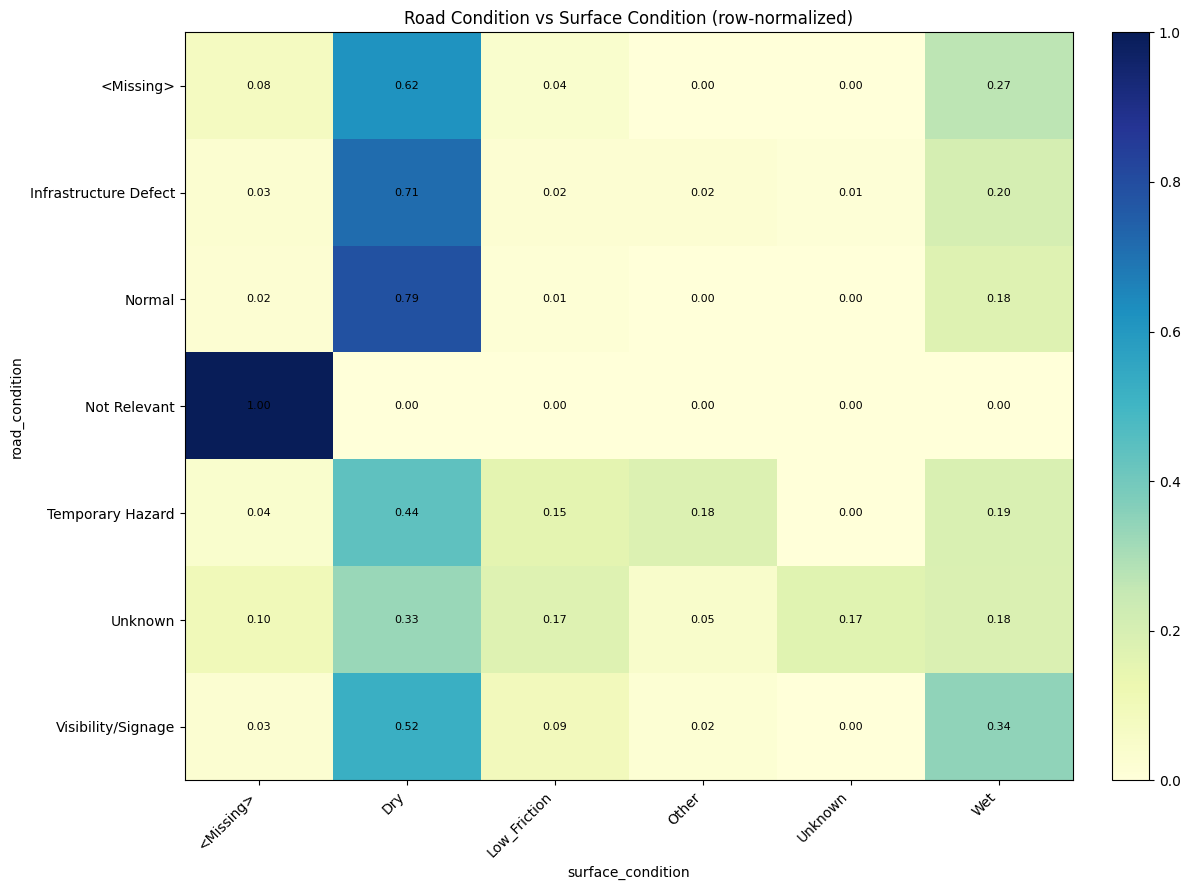

In [130]:
# code by LLM
ct = pd.crosstab(
    df["road_condition"].fillna("<Missing>"),
    df["surface_condition"].fillna("<Missing>"),
    normalize="index"
)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(ct.values, aspect="auto", cmap="YlGnBu")  # אפשר להחליף ל-"Blues" אם נוח יותר

# כתיבת הערכים על כל תא
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_xticks(np.arange(ct.shape[1]))
ax.set_yticks(np.arange(ct.shape[0]))
ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticklabels(ct.index)

ax.set_xlabel("surface_condition")
ax.set_ylabel("road_condition")
ax.set_title("Road Condition vs Surface Condition (row-normalized)")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [131]:
ct = pd.crosstab(
    df['surface_condition'].fillna('<Missing>'),
    df['road_condition'].fillna('<Missing>')
)
display(ct.style.background_gradient(axis= None))

road_condition,,Infrastructure Defect,Normal,Not Relevant,Temporary Hazard,Unknown,Visibility/Signage
surface_condition,,,,,,,
,404,13,2004,14537,12,65,3
Dry,3320,301,75055,0,137,219,62
Low_Friction,205,9,1222,0,48,115,11
Other,8,9,78,0,57,31,2
Unknown,13,4,275,0,0,111,0
Wet,1435,86,16769,0,59,122,41


In [132]:
df.loc[
    (df["surface_condition"] == "Debris_Oil") & (df["road_condition"].isna()),
    "road_condition"
] = "Temporary Hazard"

### Surface Condition & Weather

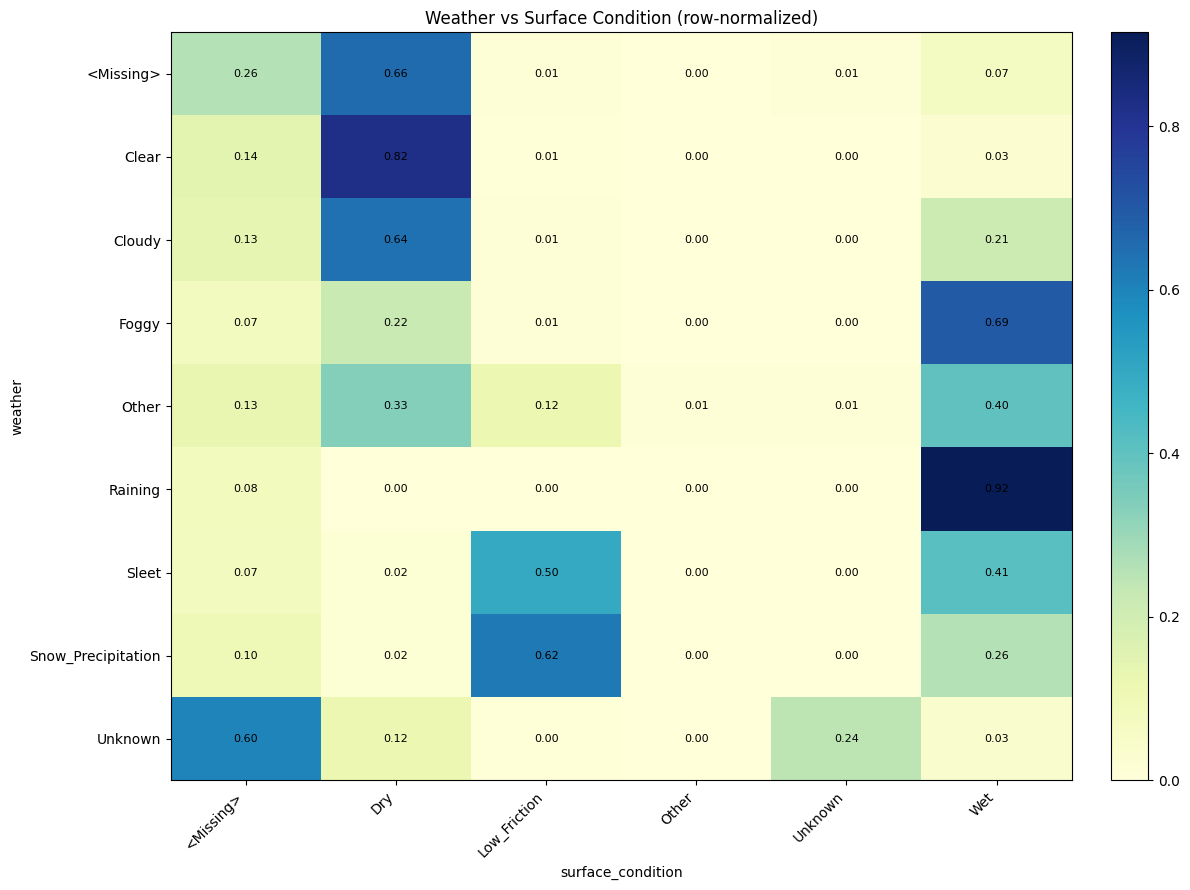

In [133]:
# code by LLM
ct = pd.crosstab(
    df["weather"].fillna("<Missing>"),
    df["surface_condition"].fillna("<Missing>"),
    normalize="index"
)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(ct.values, aspect="auto", cmap="YlGnBu")  # אפשר להחליף ל-"Blues" אם נוח יותר

# כתיבת הערכים על כל תא
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_xticks(np.arange(ct.shape[1]))
ax.set_yticks(np.arange(ct.shape[0]))
ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticklabels(ct.index)

ax.set_xlabel("surface_condition")
ax.set_ylabel("weather")
ax.set_title("Weather vs Surface Condition (row-normalized)")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [134]:
#השלמת surface_condition
df.loc[
    df["surface_condition"].isna() & df["weather"]=="Snow_Precipitation",
    "surface_condition"] = "Ice_Snow"

df.loc[
    df["surface_condition"].isna() & df["weather"].isin(["Foggy", "Raining"]),
    "surface_condition"] = "Wet"

In [135]:
#השלמת weather
df.loc[
    df["weather"].isna() & df["surface_condition"]=="Wet",
    "weather"
] = "Raining"

df.loc[
    df["weather"].isna() & df["surface_condition"]=="Ice_Snow",
    "weather"
] = "Wintry Mix"

### Light

In [136]:
#הצגת החיתוכים כדי לוודא את הלוגיקה שלנו
ct = pd.crosstab(
    df['light'].fillna('<Missing>'),
    df['time_of_day'].fillna('<Missing>')
)
display(ct.style.background_gradient(axis= None))

time_of_day,Evening,Mid_day,Morning,Night
light,,,,
,282,174,195,161
Dark,1056,19,548,2710
Dark - Unknown Lighting,268,19,182,779
Dark Lighted,7683,127,2296,18173
Daylight,27861,25514,22815,255
Low Natural Light,1994,13,2136,467
Other,294,213,343,265


In [137]:
#השלמת light
df.loc[
    df["light"].isna() & df["time_of_day"].isin(["Mid_day", "Morning"]),
    "light"
] = "Daylight"

df.loc[
    df["light"].isna() & df["time_of_day"].isin(["Night", "Evening"]),
    "light"
] = "Dark - Unknown Lighting"

בערב רמת התאורה  משתנה לפי העונה, ניתן לראות גם בטבלת חיתוכים שזה מפוזר על דרגות תאורה שונות, לא התייחסתי לזה.

### Traffic Control

In [138]:
#הצגת החיתוכים כדי לוודא את הלוגיקה שלנו
ct = pd.crosstab(
    df['traffic_control'].fillna('<Missing>'),
    df['junction'].fillna('<Missing>')
)
display(ct.style.background_gradient(axis= None))

junction,,Driveway,Interchange/Ramp,Intersection,Non-Junction,Not Relevant,Other,Roundabout
traffic_control,,,,,,,,
,4071,344,139,2395,4339,7113,250,58
No Controls,6050,2163,1046,9311,24069,6974,665,169
Other,177,47,37,475,437,90,77,36
Person,23,9,1,80,58,12,4,0
Traffic Signal,870,582,772,38383,4537,368,186,190
Unknown,17,4,5,52,37,72,48,0


In [139]:
#השלמת traffic_control
df.loc[
    df["traffic_control"].isna() & df["junction"].isin(["Interchange/Ramp", "Intersection"]),
    "traffic_control"
] = "Traffic Signal"

df.loc[
    df["traffic_control"].isna() & df["junction"]=="not relevant",
    "traffic_control"
] = "No Controls"

### Driver Substance Abuse

In [140]:
df["driver_substance_abuse"] = df["driver_substance_abuse"].fillna(0.0)

# Preprocessing for Unsupervised Learning

פרק זה עוסק בטיפול מקדים עברו עמודות נוספות שייכנסו למודלים הלא מפוקחים (בונסף לכל הדאטה שהוכן עבור מודלי הסיווג)

## Data Cleaning & Standardization

### First Harmful Event

In [141]:
df['first_harmful_event'] = df['first_harmful_event'].apply(normalize_categorial_feature)

In [142]:
harmful_map = {
    # Fixed Object
    'other object': 'fixed object',
    'other fixed object (wall, building, tunnel, etc.)': 'fixed object',
    'tree (standing)': 'fixed object',
    'other post, pole, or support': 'fixed object',
    'utility pole/light support': 'fixed object',
    'other non-fixed object': 'fixed object',
    'traffic sign support': 'fixed object',
    'mailbox': 'fixed object',
    'fence': 'fixed object',
    'thrown or falling object': 'fixed object',
    'traffic signal support': 'fixed object',
    'strikes object at rest from motor vehicle in transport': 'fixed object',
    'struck by falling, shifting cargo or anything set in motion by motor vehicle': 'fixed object',
    'construction equipment': 'fixed object',
    'cable barrier': 'fixed object',
    'cargo/equipment loss or shift': 'fixed object',
    "tree (standing)": 'fixed object',

    #animal
    'animal (live)': 'animal',
    #other vehicle
    'units separated': 'other vehicle',
    'railway train': 'other vehicle',
    'railway vehicle (train, engine)': 'other vehicle',

    #other
    'other non collision': 'other',
    'other non-collision': 'other',
    'backing': 'other',
    'fell jumped from motor vehicle': 'other',
    'spilled cargo': 'other',
    'downhill runaway': 'other',
    'u-turn': 'other',
    'explosion or fire': 'other',
    'culvert': 'other',
    'jackknife': 'other',
    'immersion': 'other',
    "immersion, full or partial": 'other',
    'bridge overhead structure': 'other',
    "impact attenuator/crash cushion": 'other',

    #other non-motorist
    'other conveyance': 'other non-motorist',
    'other non-motorist': 'other non-motorist',
    'pedalcycle': 'other non-motorist',
    'other pedalcycle': 'other non-motorist',
    'guardrail face': 'other non-motorist',
    'bicycle': 'other non-motorist',

    #road infrastructure
    'concrete traffic barrier': 'Road Infrastructure',
    'other traffic barrier': 'Road Infrastructure',
    'guardrail end terminal': 'Road Infrastructure',
    'curb': 'Road Infrastructure',
    'ditch': 'Road Infrastructure',
    'embankment': 'Road Infrastructure',
    'bridge rail': 'Road Infrastructure',
    'bridge pier or support': 'Road Infrastructure',

    'not applicable': 'unknown',
    
    'overturn/rollover': 'overturn'
}

In [143]:
df['first_harmful_event'] = df['first_harmful_event'].map(harmful_map).fillna(df['first_harmful_event']).str.title()

In [144]:
beauty_value_counts(df,'first_harmful_event')

,Count,Percentage
first_harmful_event,,
Other Vehicle,66008,56.5%
Fixed Object,14034,12.0%
Motor Vehicle In Transport,13843,11.8%
Parked Vehicle,11531,9.9%
Pedestrian,4605,3.9%
Other Non-Motorist,1587,1.4%
Off Road,1121,1.0%
Animal,1103,0.9%
Road Infrastructure,1014,0.9%


### Second Harmful Event

In [145]:
df['second_harmful_event'] = df['second_harmful_event'].apply(normalize_categorial_feature)

In [146]:
df['second_harmful_event'] = df['second_harmful_event'].map(harmful_map).fillna(df['second_harmful_event']).str.title()

In [147]:
beauty_value_counts(df,'second_harmful_event')

,Count,Percentage
second_harmful_event,,
nan,87138,74.6%
Other Vehicle,12032,10.3%
Fixed Object,8464,7.2%
Parked Vehicle,2710,2.3%
Unknown,2421,2.1%
Motor Vehicle In Transport,1327,1.1%
Overturn,710,0.6%
Off Road,707,0.6%
Pedestrian,396,0.3%


### Hit Run

In [148]:
df['hit_run'].value_counts(dropna=False)

hit_run
No      94674
Yes     18348
None     3820
Name: count, dtype: int64

In [149]:
df['hit_run'] = df['hit_run'].map({'No': 0, 'Yes': 1, 'Missing value': None})

In [150]:
beauty_value_counts(df,'hit_run')

,Count,Percentage
hit_run,,
0.000000,94674,81.0%
1.000000,18348,15.7%
nan,3820,3.3%


### At Fault

In [151]:
df['at_fault'] = df['at_fault'].apply(normalize_categorial_feature).str.title()

In [152]:
beauty_value_counts(df,'at_fault')

,Count,Percentage
at_fault,,
Driver,101387,86.8%
Unknown,13702,11.7%
Nonmotorist,1545,1.3%
Both,208,0.2%


In [153]:
#להוסיף בדיקה שכשזה הלא ממנוע זה ככה גם בפגיעה

### Collision Type

In [154]:
df['collision_type'] = df['collision_type'].apply(normalize_categorial_feature)

In [155]:
df['collision_type'].value_counts(dropna=False)

collision_type
same dir rear end                25503
single vehicle                   20028
straight movement angle          15113
other                            14280
same direction sideswipe          8835
head on left turn                 6282
front to rear                     5174
angle                             3667
sideswipe, same direction         3060
head on                           2039
same direction right turn         1972
same direction left turn          1822
opposite direction sideswipe      1584
front to front                    1048
angle meets left turn              982
unknown                            948
rear to side                       873
sideswipe, opposite direction      704
angle meets right turn             597
NaN                                499
same dir rend left turn            363
same dir rend right turn           355
same dir both left turn            352
angle meets left head on           344
rear to rear                       257
opposite d

In [156]:
collision_type_map = {
    'head on left turn': 'front to front',
    'head on': 'front to front',
    'opposite dir both left turn': 'front to front',

    'straight movement angle': 'angle',
    'sideswipe, same direction': 'angle',
    'opposite direction sideswipe': 'angle',
    'angle meets right turn': 'angle',
    'angle meets left turn': 'angle',
    'rear to side': 'angle',
    'sideswipe, opposite direction': 'angle',
    'angle meets left head on': 'angle',
    'same direction sideswipe': 'angle',

    'same direction right turn': 'same dir rear end',
    'same direction left turn': 'same dir rear end',
    'same dir rend left turn': 'same dir rear end',
    'same dir rend right turn': 'same dir rear end',
    'same dir both left turn': 'same dir rear end',
    'front to rear': 'same dir rear end',
}

In [157]:
df['collision_type'] = df['collision_type'].map(collision_type_map).fillna(df['collision_type']).str.title()

In [158]:
beauty_value_counts(df,'collision_type')

,Count,Percentage
collision_type,,
Angle,35759,30.6%
Same Dir Rear End,35541,30.4%
Single Vehicle,20028,17.1%
Other,14280,12.2%
Front To Front,9530,8.2%
Unknown,948,0.8%
nan,499,0.4%
Rear To Rear,257,0.2%


### Num Directions

In [159]:
df['num_directions'].value_counts(dropna=False)

num_directions
1.0    96316
NaN    15748
2.0     4224
0.0      411
3.0      141
4.0        2
Name: count, dtype: int64

### Lane Category

In [160]:
df['lane_category'].value_counts(dropna=False)

lane_category
single_direction        96316
missing                 14688
complex_intersection     2413
opposite_directions      1954
unknown                  1060
not_on_roadway            411
Name: count, dtype: int64

In [161]:
ct = pd.crosstab(
    df['collision_type'].fillna('<Missing>'),
    df['num_directions'].fillna('<Missing>')
)
display(ct.style.background_gradient(axis= None))

num_directions,0.000000,1.000000,2.000000,3.000000,4.000000,
collision_type,,,,,,
,0,316,0,0,0,183
Angle,149,29032,2975,94,2,3507
Front To Front,26,8217,632,15,0,640
Other,21,8188,415,28,0,5628
Rear To Rear,7,78,10,0,0,162
Same Dir Rear End,53,33852,157,3,0,1476
Single Vehicle,146,16386,28,0,0,3468
Unknown,9,247,7,1,0,684


## Domain Imputation

In [162]:
columns_to_check = ['first_harmful_event', 'second_harmful_event', 'hit_run', 'at_fault', 'collision_type', 'num_directions', 'lane_category']

df[columns_to_check].isnull().sum()

first_harmful_event       644
second_harmful_event    87138
hit_run                  3820
at_fault                    0
collision_type            499
num_directions          15748
lane_category               0
dtype: int64

### Hit Run

In [163]:
## למלא 0 בחסרים?

# Type Casting

### Missing Values Standardization 

In [164]:
columns_to_drop = [
    'report_number', 'local_case_number', 'crash_date_time','direction', 'distance_unit', 
    'road_name', 'cross_street_name','geolocation', 'intersection_type', 'off_road_description', 
    'lane_type', 'road_grade', 'road_alignment', 'road_division', 'is_bidirectional',
    'related_non_motorist', 'non_motorist_substance_abuse', 'municipality', 'number_of_lanes',
    'lane_direction'
]

df.drop(columns=columns_to_drop, inplace=True)

In [165]:
#יצירת עותק לצורך בדיקות המרה
df_before_cast = df.copy()

In [166]:
# code by LLM
#איחוד ערכים חסרים

#טקסטים שמייצגים ערכים חסרים
garbage_values = [
    'Nan', 'nan', 'NaN', 'NAN',      
    'Null', 'NULL', 'null',          
    'None', 'none', '', ' ','unknown', 'Unknown'                   
]
df = df.replace(garbage_values, np.nan)

#איחוד סוגי ערכי NA שונים לפורמט אחד
df = df.replace({None: np.nan, pd.NA: np.nan})

In [167]:
# code by LLM
# 1. חישוב המצב ב-df_before_cast (לפני הניקוי)
# סכום של ה-NaN האמיתיים + סכום של ערכי ה"זבל" הטקסטואליים
total_before = df_before_cast.isna().sum().sum() + df_before_cast.isin(garbage_values).sum().sum()

# 2. חישוב המצב ב-df (אחרי הניקוי)
# כאן הכל אמור להיות NaN סטנדרטי
total_after = df.isna().sum().sum()

print(f"סה\"כ ערכים חסרים לפני: {total_before}")
print(f"סה\"כ ערכים חסרים אחרי: {total_after}")
print(f"האם המספרים זהים? {total_before == total_after}")

סה"כ ערכים חסרים לפני: 304664
סה"כ ערכים חסרים אחרי: 304664
האם המספרים זהים? True


### Casting & Integrity Check

In [168]:
# 1) עמודות קטגוריאליות
categorical_columns = [
    'acrs_report_type', 'route_type', 'weather', 'light', 
    'junction', 'road_condition', 'surface_condition',
    'season', 'road_grade_cat', 'road_division_cat', 
    'traffic_control', 'road_alignment_cat', 'division_type', 'time_of_day',
    'left_turn', 'division', 'first_harmful_event', 'second_harmful_event', 
    'at_fault', 'collision_type', 'num_directions', 'lane_category', 'agency_name'
]

# 2) עמודות בינאריות
binary_columns = [
    'is_two_way',   
    'road_grade_Downhill', 'road_grade_Hillcrest', 'road_grade_Level', 
    'road_grade_On_Bridge', 'road_grade_Other', 'road_grade_Sag', 
    'road_grade_Uphill', 'road_alignment_Curve_Left', 'road_alignment_Curve_Right', 
    'road_alignment_Other', 'road_alignment_Straight', 
    'road_alignment_Not_Relevant', 'road_grade_Not_Relevant',
    'is_weekend', 'is_holiday', 'driver_substance_abuse', 'hit_run' 
]

# 3) עמודות מספריות
numeric_columns = ['distance', 'crash_year', 'hour', 'month', 'day_of_week']

In [169]:
# code by LLM
#בדיקת עמודות קטגוריאליות לפני המרה 
for col in categorical_columns:
    print(f"--- {col} ---")
    print(df[col].unique()) # לראות את הערכים בעיניים
    print(df[col].value_counts().head(5)) # לראות את הנפוצים
    print("\n")

--- acrs_report_type ---
['Injury Crash' 'Property Damage Crash' 'Fatal Crash']
acrs_report_type
Property Damage Crash    76972
Injury Crash             39501
Fatal Crash                369
Name: count, dtype: int64


--- route_type ---
['Highway' 'Ramp/ Spur' 'Local' 'Parking_Lot' 'Other' nan]
route_type
Highway        51380
Local          49834
Parking_Lot    12087
Other           1998
Ramp/ Spur       874
Name: count, dtype: int64


--- weather ---
['Clear' 'Raining' 'Cloudy' nan 'Snow_Precipitation' 'Other' 'Foggy'
 'Sleet']
weather
Clear                 80834
Raining               13689
Cloudy                11313
Snow_Precipitation     1371
Foggy                   421
Name: count, dtype: int64


--- light ---
['Dark Lighted' 'Dark' 'Daylight' 'Other' 'Low Natural Light'
 'Dark - Unknown Lighting']
light
Daylight                   76814
Dark Lighted               28279
Low Natural Light           4610
Dark                        4333
Dark - Unknown Lighting     1691
Name: count, d

In [170]:
# code by LLM
#בדיקת עמודות בוליאניות לפני המרה
print("=== בדיקת עמודות בינאריות ===")
for col in binary_columns:
    print(f"\n--- {col} ---")
    # הצגת כל הערכים השונים (כולל NaN)
    print(df[col].value_counts(dropna=False))

=== בדיקת עמודות בינאריות ===

--- is_two_way ---
is_two_way
1.0    97762
0.0    16589
NaN     2491
Name: count, dtype: int64

--- road_grade_Downhill ---
road_grade_Downhill
0    105106
1     11736
Name: count, dtype: int64

--- road_grade_Hillcrest ---
road_grade_Hillcrest
0    114453
1      2389
Name: count, dtype: int64

--- road_grade_Level ---
road_grade_Level
1    78773
0    38069
Name: count, dtype: int64

--- road_grade_On_Bridge ---
road_grade_On_Bridge
0    116770
1        72
Name: count, dtype: int64

--- road_grade_Other ---
road_grade_Other
0    116654
1       188
Name: count, dtype: int64

--- road_grade_Sag ---
road_grade_Sag
0    116664
1       178
Name: count, dtype: int64

--- road_grade_Uphill ---
road_grade_Uphill
0    107649
1      9193
Name: count, dtype: int64

--- road_alignment_Curve_Left ---
road_alignment_Curve_Left
0    110893
1      5949
Name: count, dtype: int64

--- road_alignment_Curve_Right ---
road_alignment_Curve_Right
0    110623
1      6219
Name: c

In [171]:
# code by LLM
#בדיקת עמודות מספריות לפני המרה
print("=== בדיקת עמודות מספריות ===")

# 1. בדיקת המשתנים הבדידים (כמו שנה, שעה)
cols_int = ['crash_year', 'hour', 'month', 'day_of_week']
for col in cols_int:
    if col in df.columns:
        print(f"\n--- {col} ---")
        # נציג ערכים ייחודיים ממוינים כדי לראות קצוות
        print(sorted(df[col].dropna().unique()))

# 2. בדיקת המשתנה הרציף (מרחק)
if 'distance' in df.columns:
    print(f"\n--- distance ---")
    print(df['distance'].describe()) # נותן min, max, mean
    # בדיקה אם יש ערכים שאינם מספרים
    non_numeric = pd.to_numeric(df['distance'], errors='coerce').isna().sum() - df['distance'].isna().sum()
    print(f"Non-numeric values (garbage): {non_numeric}")

=== בדיקת עמודות מספריות ===

--- crash_year ---
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- hour ---
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

--- month ---
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

--- day_of_week ---
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]

--- distance ---
count    1.035960e+05
mean     1.798220e+03
std      5.328077e+04
min      0.000000e+00
25%      0.000000e+00
50%      6.000000

In [172]:
# code by LLM

# המרה לקטגוריות
for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype('category')

# המרה ל-boolean (משתמשים ברשימה הבינארית שלך)
for col in binary_columns:
    if col in df.columns:
        # המרה בטוחה: קודם למספר (מטפל בטקסטים אם נשארו), ואז לבוליאני
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# המרה למספרים
# א. טיפול ב-distance (שהוא float רציף)
if 'distance' in df.columns:
    df['distance'] = pd.to_numeric(df['distance'], errors='coerce')

# ב. טיפול בשאר המספריים (שהם שלמים - Int64)
# (לוקחים מתוך הרשימה שלך את כל מה שהוא לא distance)
cols_int = [col for col in numeric_columns if col != 'distance']

for col in cols_int:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# --- שלב 3: בדיקה סופית ---
df.dtypes.to_frame(name='Data Type')

,Data Type
agency_name,category
acrs_report_type,category
hit_run,Int64
route_type,category
distance,float64
at_fault,category
collision_type,category
weather,category
surface_condition,category
light,category


In [173]:
# code by LLM
def check_conversion_integrity(df_old, df_new):
    """
    Compares valid value counts between two dataframes to ensure data integrity 
    after type casting. Returns a summary DataFrame.
    """
    # רשימת ערכים שנחשבים כ-Null במקור
    garbage_list = ['Nan', 'nan', 'NaN', 'NAN', 'Null', 'NULL', 'null', 'None', 'none', '', ' ', 'unknown', 'Unknown']
    
    results = []
    
    for col in df_new.columns:
        if col not in df_old.columns:
            continue
            
        # חישוב כמות ערכים תקינים במקור (לא NaN ולא ברשימת הזבל)
        valid_mask_old = df_old[col].notna() & ~df_old[col].isin(garbage_list)
        count_old = valid_mask_old.sum()
        
        # חישוב כמות ערכים תקינים בחדש (לא NaN)
        count_new = df_new[col].count()
        
        # חישוב ההפרש
        diff = count_new - count_old
        
        results.append({
            'column_name': col,
            'count_before': int(count_old),
            'count_after': int(count_new),
            'difference': int(diff),
            'status_ok': diff == 0
        })
        
    # החזרת דאטה-פריים ללא הדפסה
    return pd.DataFrame(results)

# הרצת הבדיקה והצגת התוצאה
integrity_df = check_conversion_integrity(df_before_cast, df)
integrity_df

,column_name,count_before,count_after,difference,status_ok
0,agency_name,116842,116842,0,True
1,acrs_report_type,116842,116842,0,True
2,hit_run,113022,113022,0,True
3,route_type,116173,116173,0,True
4,distance,103596,103596,0,True
5,at_fault,103140,103140,0,True
6,collision_type,115395,115395,0,True
7,weather,108114,108114,0,True
8,surface_condition,100549,100549,0,True
9,light,116842,116842,0,True


In [174]:
# code by LLM
def check_binary_sum_integrity(df_old, df_new, cols_list):
    """
    Compares the sum of values in binary columns between two dataframes 
    to ensure True/1 values were preserved. Returns a summary DataFrame.
    """
    results = []
    
    for col in cols_list:
        # בדיקה שהעמודה קיימת בשני הדאטה-פריימים
        if col not in df_new.columns or col not in df_old.columns:
            continue
            
        # סכום בישן: המרה למספר (כדי לתפוס גם מחרוזות '1') וסכימה
        # errors='coerce' יהפוך ערכי זבל ל-NaN שלא נספרים בסכום
        sum_old = pd.to_numeric(df_old[col], errors='coerce').sum()
        
        # סכום בחדש
        sum_new = df_new[col].sum()
        
        diff = sum_new - sum_old
        
        results.append({
            'column_name': col,
            'sum_before': float(sum_old),
            'sum_after': float(sum_new),
            'difference': float(diff),
            'status_ok': diff == 0
        })
        
    return pd.DataFrame(results)

# הרצת הבדיקה
binary_integrity_df = check_binary_sum_integrity(df_before_cast, df, binary_columns)
binary_integrity_df

,column_name,sum_before,sum_after,difference,status_ok
0,is_two_way,97762.0,97762.0,0.0,True
1,road_grade_Downhill,11736.0,11736.0,0.0,True
2,road_grade_Hillcrest,2389.0,2389.0,0.0,True
3,road_grade_Level,78773.0,78773.0,0.0,True
4,road_grade_On_Bridge,72.0,72.0,0.0,True
5,road_grade_Other,188.0,188.0,0.0,True
6,road_grade_Sag,178.0,178.0,0.0,True
7,road_grade_Uphill,9193.0,9193.0,0.0,True
8,road_alignment_Curve_Left,5949.0,5949.0,0.0,True
9,road_alignment_Curve_Right,6219.0,6219.0,0.0,True


# Final Feature Set Overview

- `acrs_report_type`: Target column (the type of accident).
- `route_type`: The type of route or path (e.g., local or highway).
- `distance`: The distance from milestone.
- `weather`: The weather conditions at the time of the accident.
- `light`: The lighting conditions during the accident.
- `driver_substance_abuse`: Indicates whether the driver was under the influence of alcohol, drugs, or medication.
- `junction`: The type of junction where the incident occurred.
- `road_alignment`: The road's alignment or curve (e.g., a bend or straight).
- `road_condition`: The road conditions (e.g., paving, obstructions, or damage).
- `road_division`: The road division (e.g., multiple lanes in different directions).
- `surface_condition_simple`: The surface condition at the time of the accident (expanded categorical).
- `surface_condition_aggressive`: The surface condition at the time of the accident (limited categorical).
- `crash_year`: The year of the crash.
- `hour`: The hour the incident occurred.
- `month`: The month the incident occurred.
- `day_of_week`: The day of the week the incident occurred.
- `is_weekend`: Whether the accident occurred on the weekend.
- `time_of_day`: The time of day (morning, evening, night).
- `season`: The season during the accident.
- `is_holiday`: Whether the accident occurred during a holiday.
- `road_grade_cat`: Road grade, a categorical column for the assessment of the road.
- `road_division_cat`: Categorical column describing the road division and directionality (bi-directional or uni-directional).
- `is_two_way, is_divided, division_type, has_left_turn`: Binary columns derived from `road_division`, indicating whether the road is two-way, divided, the type of division, and whether there is a left turn for a two-way road.
- `road_grade_Downhill, road_grade_Hillcrest, road_grade_Level, road_grade_On_Bridge, road_grade_Other, road_grade_Sag, road_grade_Uphill, road_grade_Not_Relevant`: Binary columns derived from `road_grade` for multi-hot encoding, indicating various grades of the road (e.g., downhill, uphill, level, etc.).
- `road_alignment_Curve_Left, road_alignment_Curve_Right, road_alignment_Other, road_alignment_Straight, road_alignment_Not_Relevant`: Binary columns derived from `road_alignment` for multi-hot encoding, indicating various alignments of the road (e.g., left curve, right curve, straight, etc.).

#### Additional Features for Unsupervised Model:
- `first_harmful_event`: The first event that caused the accident (e.g., collision with an object, animal, or another vehicle).
- `second_harmful_event`: The second event, if applicable, that contributed to the accident.
- `hit_run`: Indicates whether the accident involved a hit-and-run (whether the driver fled the scene).
- `at_fault`: Indicates whether the driver was at fault in the accident.
- `collision_type`: The type of collision that occurred (e.g., rear-end, side-swipe, head-on).

# Exporting Processed Data for Modeling

In [ ]:
# df.to_parquet(
#     'montgomery_crash_reporting_processed.parquet',
#     index=False,
#     engine='pyarrow',
#     compression='snappy'
# )